In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


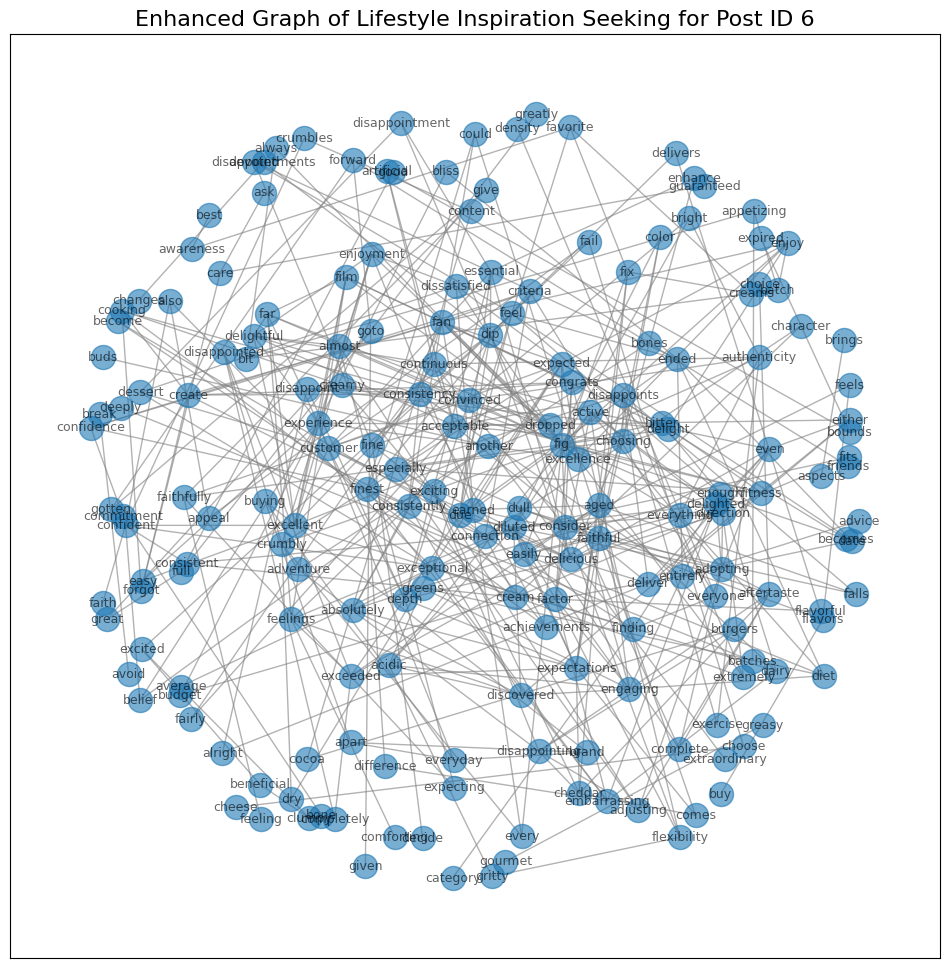

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')


df_filtered = df[df['Post ID'] == 6]
comments = df_filtered['Comment'].tolist()


cleaned_texts = []
for text in comments:
    tokens = word_tokenize(text.lower())
    filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    cleaned_texts.append(' '.join(filtered_tokens))


vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(cleaned_texts)
features = vectorizer.get_feature_names_out()


similarity_matrix = cosine_similarity(X)
G = nx.Graph()

for i in range(similarity_matrix.shape[0]):
    for j in range(i + 1, similarity_matrix.shape[1]):
        if similarity_matrix[i, j] > 0.2:
            G.add_edge(features[i], features[j], weight=similarity_matrix[i, j])


pos = nx.spring_layout(G, k=0.5, iterations=50)


plt.figure(figsize=(12, 12))
nx.draw_networkx(G, pos, edge_color='gray', alpha=0.6, with_labels=True, font_size=9)
plt.title('Enhanced Graph of Lifestyle Inspiration Seeking for Post ID 6', fontsize=16)
plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# بارگذاری داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# انتخاب داده‌های مورد نظر
comments = df['Comment']  # فرض می‌کنیم ستون نظرات 'Comment' نام دارد

# پیش‌پردازش داده‌ها
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())
    lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return ' '.join(lemmatized_words)

processed_texts = comments.apply(preprocess)


In [ ]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_texts)
feature_names = vectorizer.get_feature_names_out()

# محاسبه ماتریس شباهت
similarity_matrix = cosine_similarity(tfidf_matrix)


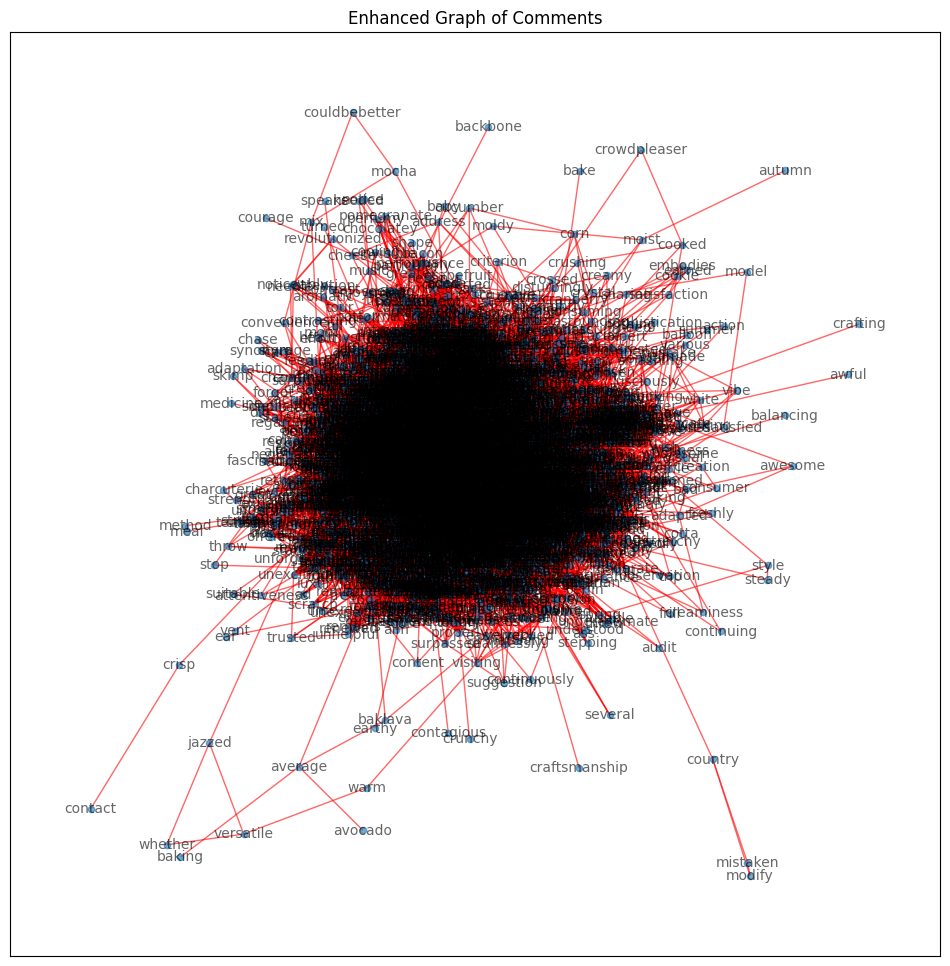

In [ ]:
# ساخت گراف
G = nx.Graph()
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        if similarity_matrix[i, j] > 0.2:  # آستانه شباهت می‌تواند تغییر کند
            G.add_edge(feature_names[i], feature_names[j], weight=similarity_matrix[i, j])

# رسم گراف
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.05, iterations=50)  # بهینه‌سازی چیدمان گراف
nx.draw_networkx(G, pos, node_size=20, alpha=0.6, edge_color='r', font_size=10)
plt.title('Enhanced Graph of Comments')
plt.show()


In [ ]:
import gc


var_names = ['large_var1', 'large_var2']


for var in var_names:
    if var in locals() or var in globals():
        exec(f'del {var}')


gc.collect()


32

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


comments = ["This is a sample comment", "Another example comment for testing"]


all_words = []
for comment in comments:
    words = word_tokenize(comment.lower())
    words = [word for word in words if word.isalpha() and word not in stopwords.words('english')]
    all_words.extend(words)


word_freq = Counter(all_words)

print(word_freq)


Counter({'comment': 2, 'sample': 1, 'another': 1, 'example': 1, 'testing': 1})


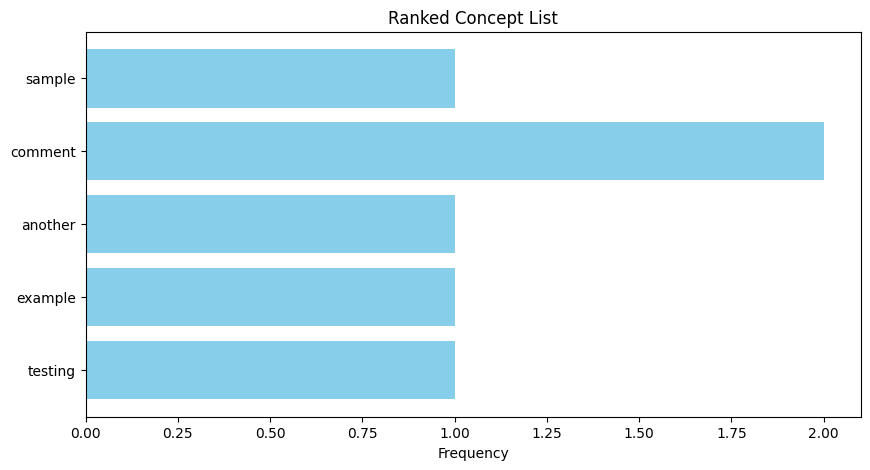

In [ ]:
import matplotlib.pyplot as plt


features = list(word_freq.keys())
frequencies = list(word_freq.values())


plt.figure(figsize=(10, 5))
plt.barh(features, frequencies, color='skyblue')
plt.xlabel('Frequency')
plt.title('Ranked Concept List')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
import pandas as pd


from google.colab import drive
drive.mount('/content/drive')


file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')


label_counts = df['Sentiment'].value_counts()


total_comments = len(df)
positive_comments = label_counts.get('LABEL_2', 0)
neutral_comments = label_counts.get('LABEL_1', 0)
negative_comments = label_counts.get('LABEL_0', 0)

positive_percentage = (positive_comments / total_comments) * 100
neutral_percentage = (neutral_comments / total_comments) * 100
negative_percentage = (negative_comments / total_comments) * 100

print(f"Positive comments: {positive_percentage:.2f}%")
print(f"Neutral comments: {neutral_percentage:.2f}%")
print(f"Negative comments: {negative_percentage:.2f}%")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Positive comments: 59.19%
Neutral comments: 20.30%
Negative comments: 20.51%


In [ ]:
import pandas as pd


file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')


df.columns = df.columns.str.strip()

sentiment_mapping = {'LABEL_0': -1, 'LABEL_1': 0, 'LABEL_2': 1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_mapping)


average_sentiments = df.groupby('Post ID')['Sentiment_Score'].mean().reset_index()


average_sentiments.columns = ['Post ID', 'Average Sentiment Score']


print(average_sentiments)


average_sentiments.to_csv('/content/drive/My Drive/Average_Sentiments_per_Post.csv', index=False)


     Post ID  Average Sentiment Score
0          1                -0.031250
1          2                 0.313725
2          3                 0.168831
3          4                -0.080645
4          5                 0.436893
..       ...                      ...
513      514                 0.360000
514      515                 0.016949
515      516                 0.184783
516      517                 1.000000
517      518                 0.114286

[518 rows x 2 columns]


In [ ]:
import pandas as pd


file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')


df.columns = df.columns.str.strip()

sentiment_mapping = {'LABEL_0': -1, 'LABEL_1': 0, 'LABEL_2': 1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_mapping)


average_sentiments = df.groupby('Post ID')['Sentiment_Score'].mean().reset_index()


average_sentiments.columns = ['Post ID', 'Average Sentiment Score']


positive_posts = average_sentiments[average_sentiments['Average Sentiment Score'] > 0]
neutral_posts = average_sentiments[average_sentiments['Average Sentiment Score'] == 0]
negative_posts = average_sentiments[average_sentiments['Average Sentiment Score'] < 0]


positive_posts['Category'] = 'Positive'
neutral_posts['Category'] = 'Neutral'
negative_posts['Category'] = 'Negative'

final_df = pd.concat([positive_posts, neutral_posts, negative_posts], ignore_index=True)
final_df = final_df[['Category', 'Post ID', 'Average Sentiment Score']]


print(final_df)


final_df.to_csv('/content/drive/My Drive/Categorized_Sentiments_per_Post.csv', index=False)


     Category  Post ID  Average Sentiment Score
0    Positive        2                 0.313725
1    Positive        3                 0.168831
2    Positive        5                 0.436893
3    Positive        6                 0.112150
4    Positive        7                 0.586957
..        ...      ...                      ...
513  Negative      479                -0.238095
514  Negative      488                -0.352381
515  Negative      507                -0.097561
516  Negative      508                -0.134615
517  Negative      511                -0.187500

[518 rows x 3 columns]


<ipython-input-17-b960b63be35b>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_posts['Category'] = 'Positive'
<ipython-input-17-b960b63be35b>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neutral_posts['Category'] = 'Neutral'
<ipython-input-17-b960b63be35b>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

In [ ]:
import pandas as pd

# بارگذاری داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# تغییر نام ستون 'Sentiment' به 'Sentiment' اگر لازم باشد
df.columns = df.columns.str.strip()

# تبدیل برچسب‌های احساسی به اعداد
sentiment_mapping = {'LABEL_0': -1, 'LABEL_1': 0, 'LABEL_2': 1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_mapping)

# محاسبه میانگین احساسات برای هر پست
average_sentiments = df.groupby('Post ID')['Sentiment_Score'].mean().reset_index()

# نام‌گذاری ستون‌ها
average_sentiments.columns = ['Post ID', 'Average Sentiment Score']

# دسته‌بندی پست‌ها بر اساس میانگین احساسات
positive_posts = average_sentiments[average_sentiments['Average Sentiment Score'] > 0].copy()
neutral_posts = average_sentiments[average_sentiments['Average Sentiment Score'] == 0].copy()
negative_posts = average_sentiments[average_sentiments['Average Sentiment Score'] < 0].copy()

# ایجاد دسته‌بندی‌ها
positive_posts.loc[:, 'Category'] = 'Positive'
neutral_posts.loc[:, 'Category'] = 'Neutral'
negative_posts.loc[:, 'Category'] = 'Negative'

# ایجاد DataFrame نهایی با دسته‌بندی
final_df = pd.concat([positive_posts, neutral_posts, negative_posts], ignore_index=True)
final_df = final_df[['Category', 'Post ID', 'Average Sentiment Score']]

# نمایش نتایج
print(final_df)

# ذخیره نتایج در یک فایل CSV
final_df.to_csv('/content/drive/My Drive/Categorized_Sentiments_per_Post.csv', index=False)


     Category  Post ID  Average Sentiment Score
0    Positive        2                 0.313725
1    Positive        3                 0.168831
2    Positive        5                 0.436893
3    Positive        6                 0.112150
4    Positive        7                 0.586957
..        ...      ...                      ...
513  Negative      479                -0.238095
514  Negative      488                -0.352381
515  Negative      507                -0.097561
516  Negative      508                -0.134615
517  Negative      511                -0.187500

[518 rows x 3 columns]


In [ ]:
import pandas as pd

# بارگذاری داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# تغییر نام ستون 'Sentiment' به 'Sentiment' اگر لازم باشد
df.columns = df.columns.str.strip()

# تبدیل برچسب‌های احساسی به اعداد
sentiment_mapping = {'LABEL_0': -1, 'LABEL_1': 0, 'LABEL_2': 1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_mapping)

# محاسبه میانگین احساسات برای هر پست
average_sentiments = df.groupby('Post ID')['Sentiment_Score'].mean().reset_index()

# نام‌گذاری ستون‌ها
average_sentiments.columns = ['Post ID', 'Average Sentiment Score']

# دسته‌بندی پست‌ها بر اساس میانگین احساسات
positive_posts = average_sentiments[average_sentiments['Average Sentiment Score'] > 0].copy()
neutral_posts = average_sentiments[average_sentiments['Average Sentiment Score'] == 0].copy()
negative_posts = average_sentiments[average_sentiments['Average Sentiment Score'] < 0].copy()

# ایجاد دسته‌بندی‌ها
positive_posts.loc[:, 'Category'] = 'Positive'
neutral_posts.loc[:, 'Category'] = 'Neutral'
negative_posts.loc[:, 'Category'] = 'Negative'

# ایجاد DataFrame نهایی با دسته‌بندی
final_df = pd.concat([positive_posts, neutral_posts, negative_posts], ignore_index=True)
final_df = final_df[['Category', 'Post ID', 'Average Sentiment Score']]

# محاسبه درصد هر دسته
total_posts = len(final_df)
positive_percentage = (len(positive_posts) / total_posts) * 100
neutral_percentage = (len(neutral_posts) / total_posts) * 100
negative_percentage = (len(negative_posts) / total_posts) * 100

print(f"Positive posts: {positive_percentage:.2f}%")
print(f"Neutral posts: {neutral_percentage:.2f}%")
print(f"Negative posts: {negative_percentage:.2f}%")

# ذخیره نتایج در یک فایل CSV
final_df.to_csv('/content/drive/My Drive/Categorized_Sentiments_per_Post.csv', index=False)


Positive posts: 85.91%
Neutral posts: 0.97%
Negative posts: 13.13%


In [ ]:
import pandas as pd
from google.colab import drive

# اتصال به گوگل درایو
drive.mount('/content/drive')

# خواندن داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/UGC_with_clusters.csv'
df = pd.read_csv(file_path)

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())


Mounted at /content/drive
   Post ID  CommentID                                           ParentID  \
0        1          1                                                  0   
1        1          2            This product really helped me, love it!   
2        1          3       Glad to hear that! It s my favorite as well    
3        1          4            Really? I found it quite disappointing    
4        1          5  Interesting, I had a different experience  Why...   

                                             Comment  Likes       Timestamp  \
0            This product really helped me, love it!    5.0  5/7/2023 10:00   
1       Glad to hear that! It s my favorite as well     2.0  5/7/2023 10:05   
2            Really? I found it quite disappointing     3.0  5/7/2023 10:10   
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15   
4          It just didn t work as advertised for me     4.0  5/7/2023 10:20   

           embedding  cluster  
0   [3.353

In [ ]:
# ایجاد یک جدول محوری برای نمایش پست‌ها و کلاستر آنها
pivot_table = df.pivot_table(index='Post ID', values='cluster', aggfunc='first')

# نمایش جدول محوری
print(pivot_table)


         cluster
Post ID         
1              0
2              0
3              0
4              0
5              9
...          ...
514            0
515            0
516            8
517            9
518            7

[518 rows x 1 columns]


In [ ]:
import pandas as pd
from google.colab import drive

# اتصال به گوگل درایو
drive.mount('/content/drive')

# خواندن داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/UGC_with_clusters.csv'
df = pd.read_csv(file_path)

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                           ParentID  \
0        1          1                                                  0   
1        1          2            This product really helped me, love it!   
2        1          3       Glad to hear that! It s my favorite as well    
3        1          4            Really? I found it quite disappointing    
4        1          5  Interesting, I had a different experience  Why...   

                                             Comment  Likes       Timestamp  \
0            This product really helped me, love it!    5.0  5/7/2023 10:00   
1       Glad to hear that! It s my favorite as well     2.0  5/7/2023 10:05   
2            Really? I found it quite disappointing     3.0  5/7/2023 10:10   
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15   
4          It just 

In [ ]:
# تعیین احساسات برای هر کلاستر
def get_sentiment(cluster):
    if cluster in [0, 1, 2]:
        return 'Neutral'
    elif cluster in [3, 4, 5, 6]:
        return 'Negative'
    elif cluster in [7, 8, 9]:
        return 'Positive'
    else:
        return 'Unknown'

df['Sentiment'] = df['cluster'].apply(get_sentiment)


In [ ]:
# دسته‌بندی پست‌ها بر اساس احساسات
positive_posts = df[df['Sentiment'] == 'Positive']['Post ID'].tolist()
neutral_posts = df[df['Sentiment'] == 'Neutral']['Post ID'].tolist()
negative_posts = df[df['Sentiment'] == 'Negative']['Post ID'].tolist()

# ایجاد DataFrame جدید برای نمایش نتایج
result_df = pd.DataFrame({
    'Positive Posts': [', '.join(map(str, positive_posts))],
    'Neutral Posts': [', '.join(map(str, neutral_posts))],
    'Negative Posts': [', '.join(map(str, negative_posts))]
})

# نمایش نتایج
print(result_df)


                                      Positive Posts  \
0  1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3...   

                                       Neutral Posts  \
0  1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1...   

                                      Negative Posts  
0  1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2...  


In [ ]:
output_file_path = '/content/drive/My Drive/Post_Sentiment_Classification.csv'
result_df.to_csv(output_file_path, index=False)
print(f"Results saved to {output_file_path}")


Results saved to /content/drive/My Drive/Post_Sentiment_Classification.csv


In [ ]:
output_file_path = '/content/drive/My Drive/Post_Cluster_Mapping.csv'
pivot_table.to_csv(output_file_path)
print(f"Results saved to {output_file_path}")


Results saved to /content/drive/My Drive/Post_Cluster_Mapping.csv


In [ ]:
import pandas as pd
from google.colab import drive

# اتصال به گوگل درایو
drive.mount('/content/drive')

# خواندن داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/UGC_with_clusters.csv'
df = pd.read_csv(file_path)

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# تعیین احساسات برای هر کلاستر
def get_sentiment(cluster):
    if cluster in [0, 1, 2]:
        return 'Neutral'
    elif cluster in [3, 4, 5, 6]:
        return 'Negative'
    elif cluster in [7, 8, 9]:
        return 'Positive'
    else:
        return 'Unknown'

df['Sentiment'] = df['cluster'].apply(get_sentiment)

# دسته‌بندی پست‌ها بر اساس احساسات
positive_posts = df[df['Sentiment'] == 'Positive']['Post ID'].tolist()
neutral_posts = df[df['Sentiment'] == 'Neutral']['Post ID'].tolist()
negative_posts = df[df['Sentiment'] == 'Negative']['Post ID'].tolist()

# ایجاد DataFrame جدید برای نمایش نتایج
result_df = pd.DataFrame({
    'Category': ['Positive Posts', 'Neutral Posts', 'Negative Posts'],
    'Posts': [
        ', '.join(map(str, positive_posts)),
        ', '.join(map(str, neutral_posts)),
        ', '.join(map(str, negative_posts))
    ]
})

# نمایش نتایج
print(result_df)

# ذخیره نتایج به فایل جدید (در صورت نیاز)
output_file_path = '/content/drive/My Drive/Post_Sentiment_Classification.csv'
result_df.to_csv(output_file_path, index=False)
print(f"Results saved to {output_file_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                           ParentID  \
0        1          1                                                  0   
1        1          2            This product really helped me, love it!   
2        1          3       Glad to hear that! It s my favorite as well    
3        1          4            Really? I found it quite disappointing    
4        1          5  Interesting, I had a different experience  Why...   

                                             Comment  Likes       Timestamp  \
0            This product really helped me, love it!    5.0  5/7/2023 10:00   
1       Glad to hear that! It s my favorite as well     2.0  5/7/2023 10:05   
2            Really? I found it quite disappointing     3.0  5/7/2023 10:10   
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15   
4          It just 

In [ ]:
# اتصال به گوگل درایو
from google.colab import drive
drive.mount('/content/drive')

# بارگذاری کتابخانه‌های مورد نیاز
import pandas as pd

# مسیر فایل JSON
json_file_path = '/content/drive/My Drive/comments_tree.json'

# بارگذاری داده‌ها از فایل JSON
with open(json_file_path, 'r', encoding='utf-8') as file:
    data = file.readlines()

# تبدیل داده‌های JSON به DataFrame
df = pd.read_json(''.join(data), lines=True)

# نمایش ستون‌های DataFrame
print(df.columns)

# نمایش چند ردیف اول داده‌ها
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Index(['Post ID', 'CommentID', 'ParentID', 'Comment', 'Likes', 'Timestamp'], dtype='object')
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes  \
0            This product really helped me, love it!    5.0   
1        Glad to hear that! It s my favorite as well    2.0   
2             Really? I found it quite disappointing    3.0   
3  Interesting, I had a different experience  Why...    1.0   
4           It just didn t work as adverti

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install transformers

from transformers import BertTokenizer, BertModel
import torch

# BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')


def embed_text(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()


if 'Comment' in df.columns:
    df['embedding'] = df['Comment'].apply(embed_text)
else:
    raise KeyError("The column 'Comment' does not exist in the DataFrame")


df.head()


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

,Post ID,CommentID,ParentID,Comment,Likes,Timestamp,embedding
0,1,1,0,"This product really helped me, love it!",5.0,2023-05-07 10:00:00,"[0.47253388, -0.036070738, 0.3617484, -0.05761..."
1,1,2,0,Glad to hear that! It s my favorite as well,2.0,2023-05-07 10:05:00,"[-0.021289257, 0.18440683, 0.26987144, -0.0663..."
2,1,3,Glad to hear that! It s my favorite as well,Really? I found it quite disappointing,3.0,2023-05-07 10:10:00,"[-0.045906637, 0.014819899, -0.026091894, -0.1..."
3,1,4,Glad to hear that! It s my favorite as well,"Interesting, I had a different experience Why...",1.0,2023-05-07 10:15:00,"[-0.053433247, -0.02348145, -0.081934966, 0.11..."
4,1,5,Glad to hear that! It s my favorite as well,It just didn t work as advertised for me,4.0,2023-05-07 10:20:00,"[0.2680381, 0.025399733, 0.3823335, 0.2940006,..."


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

# اطمینان از وجود ستون 'Comment'
if 'Comment' in df.columns:
    # امبدینگ تمام نظرات با استفاده از مدل BERT
    df['embedding'] = df['Comment'].apply(embed_text)

    # تبدیل لیست امبدینگ‌ها به آرایه NumPy برای استفاده در K-means
    embeddings = np.vstack(df['embedding'].values)

    # انجام خوشه‌بندی K-means
    kmeans = KMeans(n_clusters=10, random_state=0)  # تنظیم تعداد خوشه‌ها
    df['cluster'] = kmeans.fit_predict(embeddings)

    # ذخیره دیتافریم به فایل CSV
    df.to_csv('/content/drive/My Drive/your_output_file.csv', index=False)

    # چاپ چند ردیف اول دیتافریم برای نمایش نتایج
    print(df.head())
else:
    raise KeyError("The column 'Comment' does not exist in the DataFrame")


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes  \
0            This product really helped me, love it!    5.0   
1        Glad to hear that! It s my favorite as well    2.0   
2             Really? I found it quite disappointing    3.0   
3  Interesting, I had a different experience  Why...    1.0   
4           It just didn t work as advertised for me    4.0   

            Timestamp                                          embedding  \
0 2023-05-07 10:00:00  [0.47253388, -0.036070738, 0.3617484, -0.05761...   
1 2023-05-07 10:05:00  [-0.021289257, 0.18440683

In [ ]:
from sklearn.cluster import KMeans

# K-means
X = list(df['embedding'])
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10).fit(X)


df['cluster'] = kmeans.labels_


for cluster in range(10):
    print(f"Cluster {cluster}:")
    cluster_posts = df[df['cluster'] == cluster][['Post ID', 'Comment']].values.tolist()
    for post in cluster_posts:
        print(post)

Streaming output truncated to the last 5000 lines.
[323, 'Always the highest quality from this brand   Thank you']
[323, 'Your products always bring  smile to my face   Love it']
[323, 'This is why  always recommend your brand to friends']
[323, 'A reliable choice that never disappoints   Excellent']
[323, 'Love the innovation   You guys always lead the pack']
[324, 'Your brand is synonymous with quality   Well done']
[324, 'Appreciate the quick and efficient service   Exceptional']
[324, 'Your product makes  big difference   Thanks']
[324, 'You ve exceeded my expectations once again']
[324, 'Stellar performance  This is why  trust your brand']
[324, 'Thanks for making such  dependable product']
[324, 'Impressive results  I m  customer for life']
[324, 'You ve nailed it with this one   Truly  superior product']
[324, 'Always satisfied with your products   Keep up the great work']
[324, 'Your commitment to quality is obvious   Well worth the investment']
[324, '  Great product, even bet

In [ ]:
!pip install transformers
!pip install torch
!pip install sentence-transformers


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# خواندن داده‌ها
data = pd.read_csv('/content/drive/My Drive/UGC FINAL with Sentiments.csv', encoding='ISO-8859-1')


In [ ]:
# تبدیل احساسات به مقادیر عددی
sentiment_mapping = {'LABEL_0': 0, 'LABEL_1': 1, 'LABEL_2': 2}  # تغییرات لازم براساس خروجی مدل شما
data['Sentiment_Numeric'] = data['Sentiment'].map(sentiment_mapping)


In [ ]:
from scipy import stats

# جدا کردن داده‌ها بر اساس خوشه‌ها
clusters = data['cluster'].unique()
cluster_sentiments = [data[data['cluster'] == cluster]['Sentiment_Numeric'] for cluster in clusters]

# انجام ANOVA
f_value, p_value = stats.f_oneway(*cluster_sentiments)

print(f'F-value: {f_value}')
print(f'P-value: {p_value}')


F-value: 1095.4195696786753
P-value: 0.0


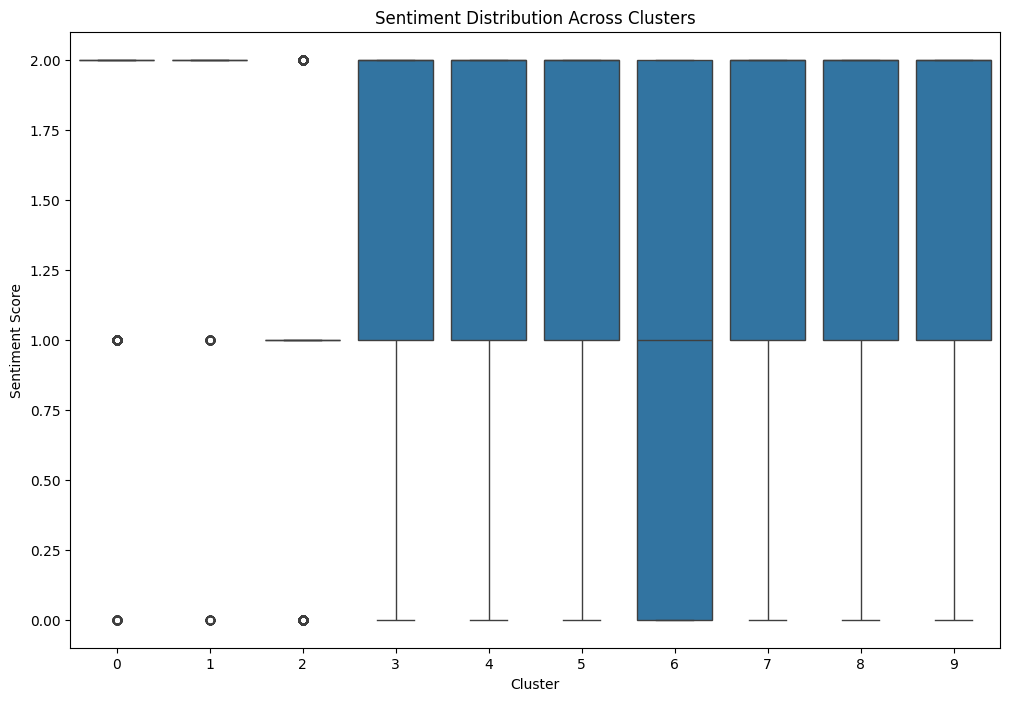

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ایجاد جعبه‌نمودار برای تجسم تفاوت‌ها بین کلاسترها
plt.figure(figsize=(12, 8))
sns.boxplot(x='cluster', y='Sentiment_Numeric', data=data)
plt.xlabel('Cluster')
plt.ylabel('Sentiment Score')
plt.title('Sentiment Distribution Across Clusters')
plt.show()


<ipython-input-10-baa28ff6258c>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Sentiment_Numeric', data=data, palette="Purples")


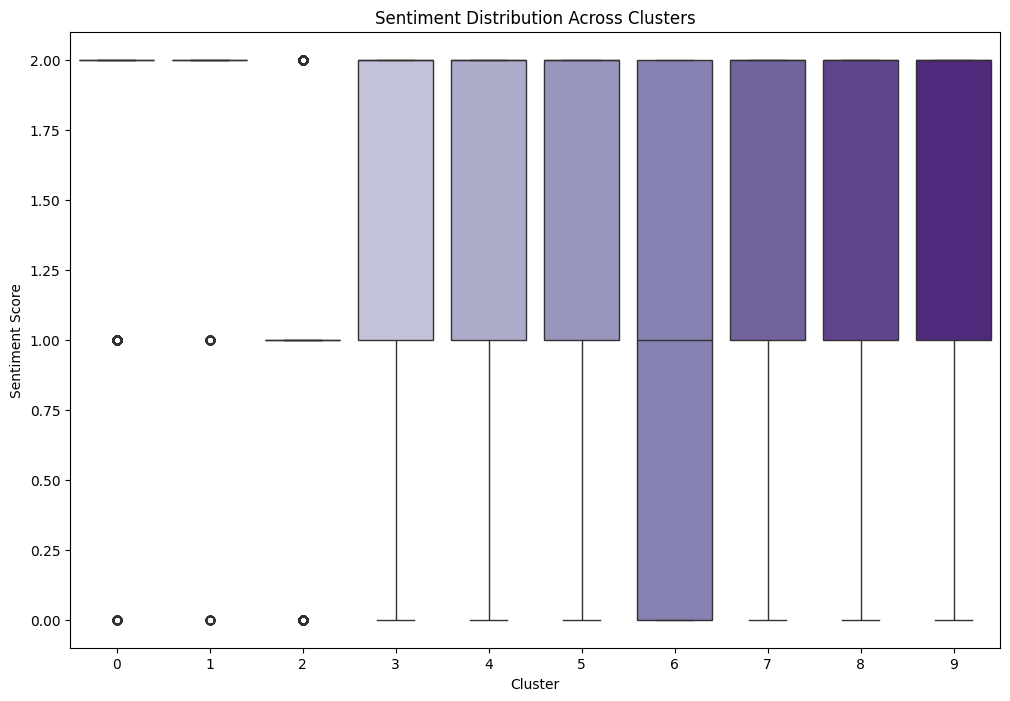

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ایجاد جعبه‌نمودار برای تجسم تفاوت‌ها بین کلاسترها
plt.figure(figsize=(12, 8))
sns.boxplot(x='cluster', y='Sentiment_Numeric', data=data, palette="Purples")
plt.xlabel('Cluster')
plt.ylabel('Sentiment Score')
plt.title('Sentiment Distribution Across Clusters')
plt.show()


In [ ]:
import pandas as pd
from transformers import pipeline
import concurrent.futures
from tqdm import tqdm
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from google.colab import drive
import torch

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# استفاده از GPU اگر موجود باشد
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# محاسبه embedding‌ها با استفاده از مدل sentence-transformers
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
data['embedding'] = list(tqdm(model.encode(data['Comment'].tolist(), batch_size=32, show_progress_bar=True)))

# انجام خوشه‌بندی K-means
X = data['embedding'].tolist()
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10).fit(X)
data['cluster'] = kmeans.labels_

# تعریف مدل تحلیل احساسات
sentiment_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment", device=0 if torch.cuda.is_available() else -1)

# تابع تحلیل احساسات
def analyze_sentiment(text):
    result = sentiment_pipeline(text)
    return result[0]['label']

# اعمال تحلیل احساسات بر ستون 'Comment' با استفاده از پردازش موازی
comments = data['Comment'].tolist()

# استفاده از ThreadPoolExecutor برای پردازش موازی
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(analyze_sentiment, comments), total=len(comments)))

# افزودن نتایج تحلیل احساسات به DataFrame
data['Sentiment'] = results

# ذخیره داده‌های جدید در فایل CSV
output_file_path = '/content/drive/My Drive/UGC FINAL with Sentiments.csv'
data.to_csv(output_file_path, index=False, encoding='ISO-8859-1')

# چاپ نام ستون‌ها
print(data.columns)

# محاسبه تعداد نظرات در هر کلاستر و احساسات
if 'cluster' in data.columns:
    cluster_sentiment_counts = data.groupby(['cluster', 'Sentiment']).size().reset_index(name='Count')

    # نمایش جدول
    print(cluster_sentiment_counts)

    # ذخیره جدول به یک فایل CSV
    output_count_file_path = '/content/drive/My Drive/Cluster_Sentiment_Counts.csv'
    cluster_sentiment_counts.to_csv(output_count_file_path, index=False, encoding='ISO-8859-1')
else:
    print("The 'cluster' column does not exist in the data.")


ModuleNotFoundError: No module named 'sentence_transformers'

In [ ]:
!pip install scikit-learn
!pip install nltk


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import nltk
from nltk.corpus import stopwords
from google.colab import drive

# دانلود stop words
nltk.download('stopwords')

# تنظیم stop words
stop_words = set(stopwords.words('english'))

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/your_output_file.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# پیش‌پردازش نظرات (توکن‌سازی و حذف توقف‌کلمات)
def preprocess(comment):
    tokens = [word for word in comment.lower().split() if word.isalpha() and word not in stop_words]
    return ' '.join(tokens)

df['processed_comment'] = df['Comment'].apply(preprocess)

# ایجاد یک دیکشنری برای ذخیره موضوعات هر کلاستر
cluster_topics = {}

# تحلیل موضوعی هر کلاستر
def analyze_topics_for_cluster(cluster_id):
    cluster_data = df[df['cluster'] == cluster_id]
    comments = cluster_data['processed_comment'].tolist()

    # تبدیل نظرات به ماتریس TF-IDF
    vectorizer = TfidfVectorizer(max_features=1000)
    X = vectorizer.fit_transform(comments)

    # آموزش مدل NMF
    nmf_model = NMF(n_components=5, random_state=0)
    W = nmf_model.fit_transform(X)
    H = nmf_model.components_

    # نمایش موضوعات
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic_idx, topic in enumerate(H):
        top_features_ind = topic.argsort()[:-6:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics.append(" ".join(top_features))
    cluster_topics[cluster_id] = topics
    print(f"Topics for Cluster {cluster_id}:")
    for idx, topic in enumerate(topics):
        print(f"Topic {idx + 1}: {topic}")

# اجرای تحلیل موضوعی برای هر کلاستر
for cluster_id in df['cluster'].unique():
    analyze_topics_for_cluster(cluster_id)

# افزودن موضوعات به DataFrame
df['topics'] = df['cluster'].map(lambda x: cluster_topics[x])

# ذخیره DataFrame به فایل CSV
output_file_path_with_topics = '/content/drive/My Drive/UGC_FINAL_with_Topics.csv'
df.to_csv(output_file_path_with_topics, index=False, encoding='ISO-8859-1')

# نمایش چند ردیف اول دیتافریم برای بررسی
print(df.head())



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Topics for Cluster 5:
Topic 1: brand trust quality every kalle
Topic 2: loyalty try satisfaction yogurt creamy
Topic 3: milk enriched kids nutrition children
Topic 4: shahi paneer dish culinary delicious
Topic 5: always perfect cheese summer satisfied
Topics for Cluster 8:
Topic 1: keep peeled eyes updates competitors
Topic 2: quality loyal commitment customer thanks
Topic 3: never disappoints disappoint brand fails
Topic 4: brand trust loyalty earned every
Topic 5: always products satisfied great expectations
Topics for Cluster 0:
Topic 1: expected brand better much standard
Topic 2: like sounds dark shot plan
Topic 3: time high delays addressed continuous
Topic 4: disappointed quality lack quite flavor
Topic 5: taste lucky expectations satisfied meet
Topics for Cluster 9:
Topic 1: beat around real issue bush
Topic 2: need go drawing back board
Topic 3: brid

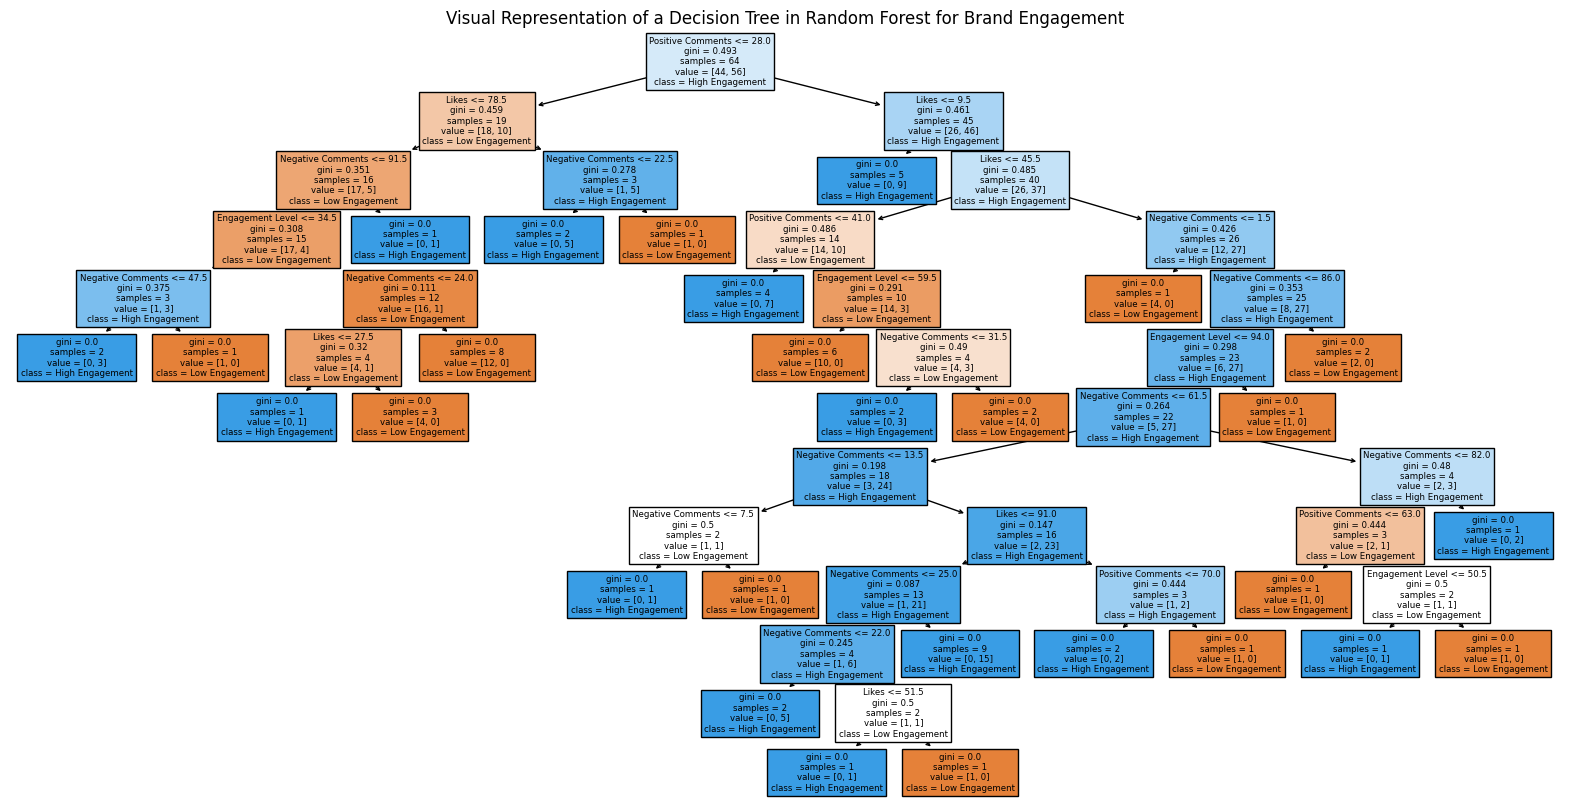

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# فرض کنید اینها متغیرهای شما هستند
features = ["Likes", "Positive Comments", "Negative Comments", "Engagement Level"]
class_names = ["Low Engagement", "High Engagement"]

# ساخت داده‌های مصنوعی برای نمونه (شما باید داده‌های واقعی خود را اینجا قرار دهید)
np.random.seed(42)
X = np.random.randint(0, 100, size=(100, 4))  # 100 نمونه و 4 ویژگی
y = np.random.choice([0, 1], size=(100,))  # 0 برای درگیری پایین و 1 برای درگیری بالا

# آموزش مدل جنگل تصادفی
clf = RandomForestClassifier(n_estimators=1, random_state=42)  # استفاده از یک درخت برای سادگی
clf.fit(X, y)

# ترسیم درخت
plt.figure(figsize=(20, 10))
plot_tree(clf.estimators_[0], filled=True, feature_names=features, class_names=class_names)
plt.title('Visual Representation of a Decision Tree in Random Forest for Brand Engagement')
plt.show()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# تحلیل موضوعی هر کلاستر
def analyze_topics_for_cluster(cluster_id):
    cluster_data = df[df['cluster'] == cluster_id]
    comments = cluster_data['processed_comment'].tolist()

    # تبدیل نظرات به ماتریس TF-IDF
    vectorizer = TfidfVectorizer(max_features=1000)
    X = vectorizer.fit_transform(comments)

    # آموزش مدل NMF
    nmf_model = NMF(n_components=5, random_state=0)
    W = nmf_model.fit_transform(X)
    H = nmf_model.components_

    # نمایش موضوعات
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic_idx, topic in enumerate(H):
        top_features_ind = topic.argsort()[:-6:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics.append(" ".join(top_features))
    cluster_topics[cluster_id] = topics
    print(f"Topics for Cluster {cluster_id}:")
    for idx, topic in enumerate(topics):
        print(f"Topic {idx + 1}: {topic}")

# اجرای تحلیل موضوعی برای هر کلاستر
for cluster_id in df['cluster'].unique():
    analyze_topics_for_cluster(cluster_id)


Topics for Cluster 5:
Topic 1: brand trust quality every kalle
Topic 2: loyalty try satisfaction yogurt creamy
Topic 3: milk enriched kids nutrition children
Topic 4: shahi paneer dish culinary delicious
Topic 5: always perfect cheese summer satisfied
Topics for Cluster 8:
Topic 1: keep peeled eyes updates competitors
Topic 2: quality loyal commitment customer thanks
Topic 3: never disappoints disappoint brand fails
Topic 4: brand trust loyalty earned every
Topic 5: always products satisfied great expectations
Topics for Cluster 0:
Topic 1: expected brand better much standard
Topic 2: like sounds dark shot plan
Topic 3: time high delays addressed continuous
Topic 4: disappointed quality lack quite flavor
Topic 5: taste lucky expectations satisfied meet
Topics for Cluster 9:
Topic 1: beat around real issue bush
Topic 2: need go drawing back board
Topic 3: bridge cross come wing time
Topic 4: get tacks brass budget sort
Topic 5: let wrap call think covered
Topics for Cluster 1:
Topic 1: 

In [ ]:
# افزودن موضوعات به DataFrame
df['topics'] = df['cluster'].map(lambda x: cluster_topics[x])

# ذخیره DataFrame به فایل CSV
output_file_path_with_topics = '/content/drive/My Drive/UGC_FINAL_with_Topics.csv'
df.to_csv(output_file_path_with_topics, index=False, encoding='ISO-8859-1')

# نمایش چند ردیف اول دیتافریم برای بررسی
print(df.head())


   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes  \
0            This product really helped me, love it!    5.0   
1        Glad to hear that! It s my favorite as well    2.0   
2             Really? I found it quite disappointing    3.0   
3  Interesting, I had a different experience  Why...    1.0   
4           It just didn t work as advertised for me    4.0   

             Timestamp                                          embedding  \
0  2023-05-07 10:00:00  [ 4.72533882e-01 -3.60707380e-02  3.61748397e-...   
1  2023-05-07 10:05:00  [-2.12892573e-02  1.84

<ipython-input-28-5a226837df02>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df, palette=purple_palette)


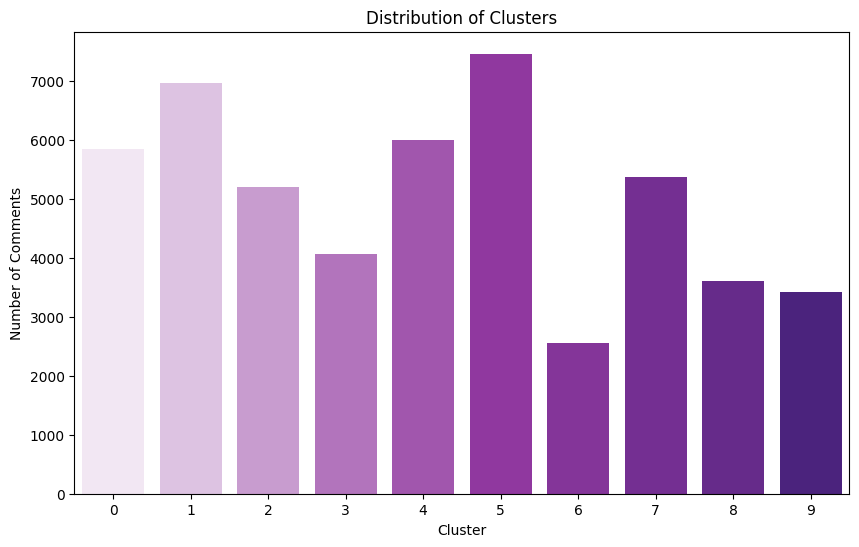

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# تعریف پالت رنگی
purple_palette = ['#f3e5f5', '#e1bee7', '#ce93d8', '#ba68c8', '#ab47bc',
                  '#9c27b0', '#8e24aa', '#7b1fa2', '#6a1b9a', '#4a148c']

# هیستوگرام برای توزیع تعداد نظرات در هر کلاستر
plt.figure(figsize=(10, 6))
sns.countplot(x='cluster', data=df, palette=purple_palette)
plt.title('Distribution of Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Comments')
plt.show()


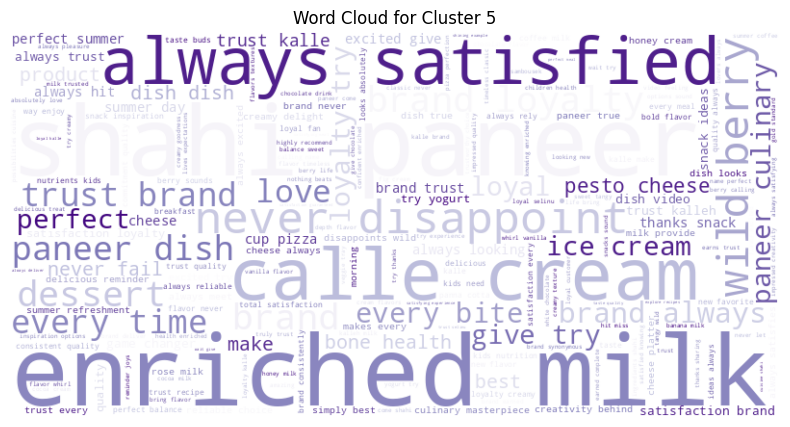

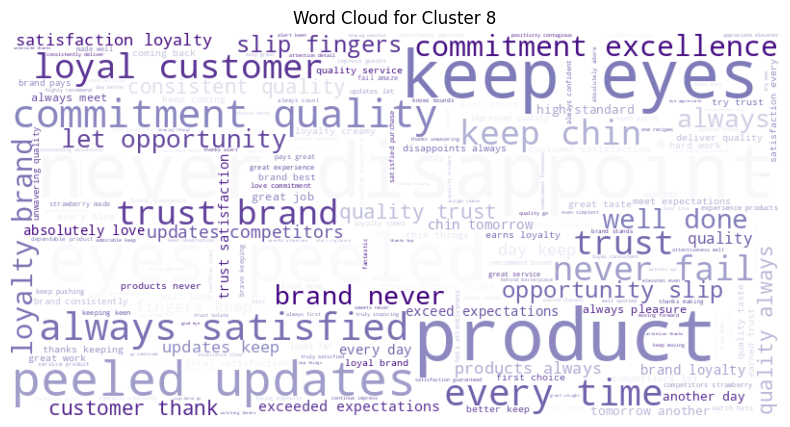

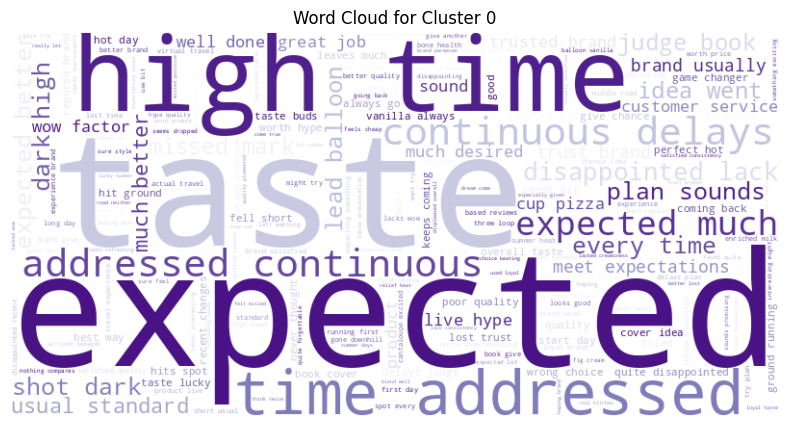

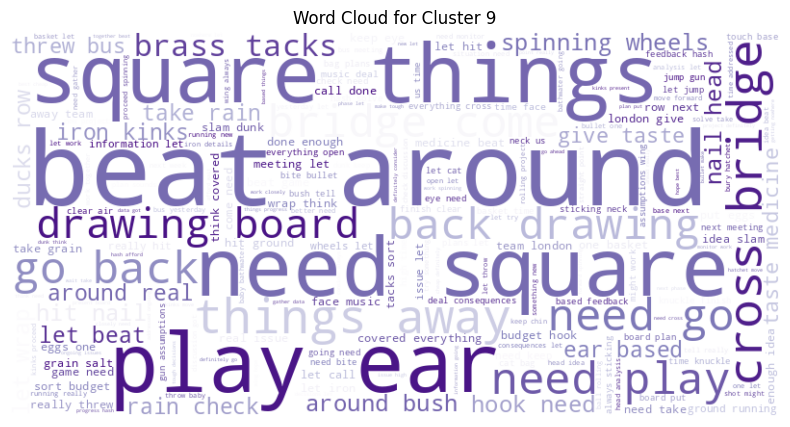

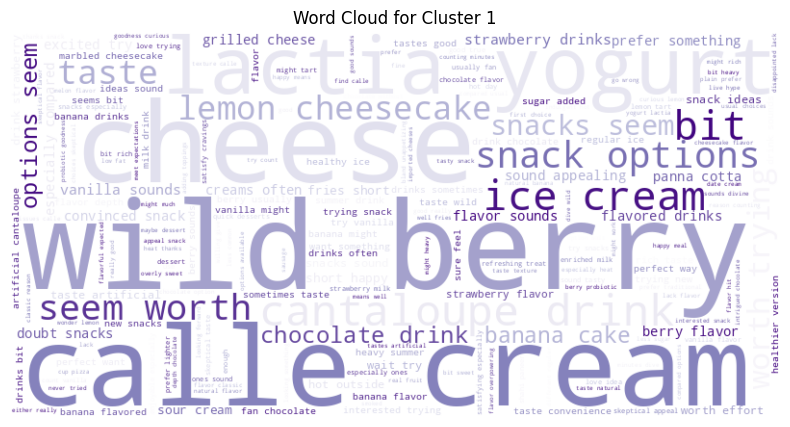

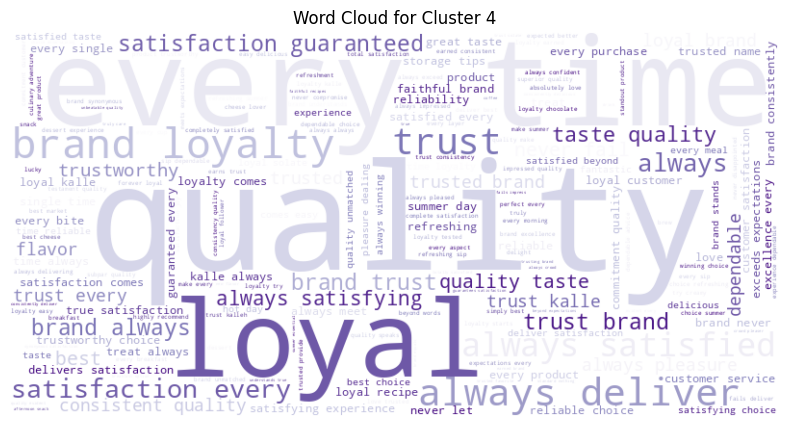

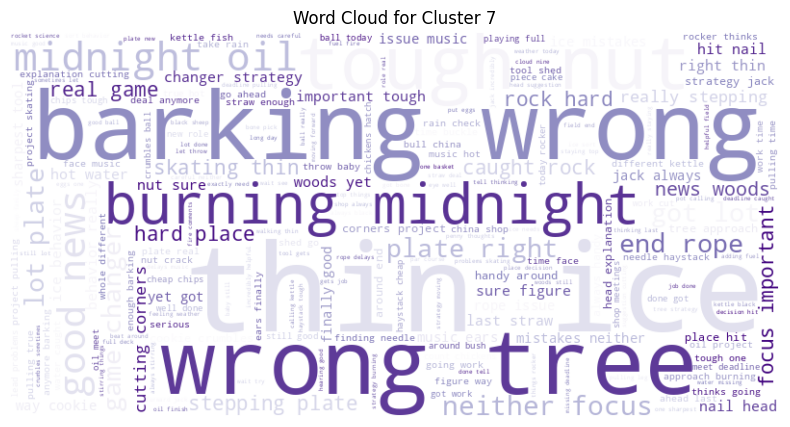

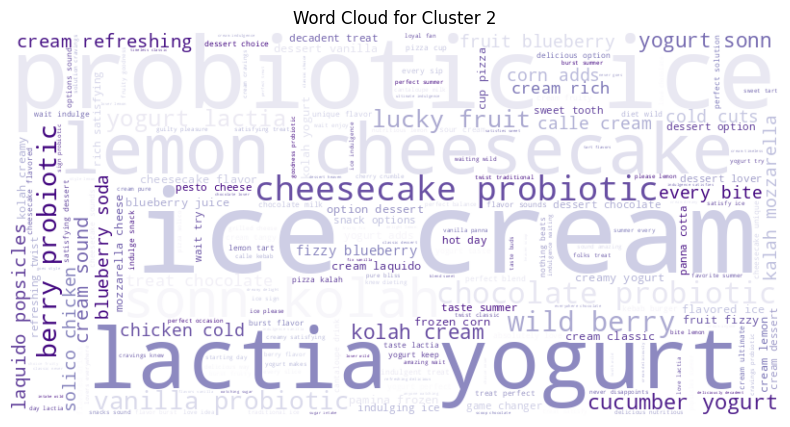

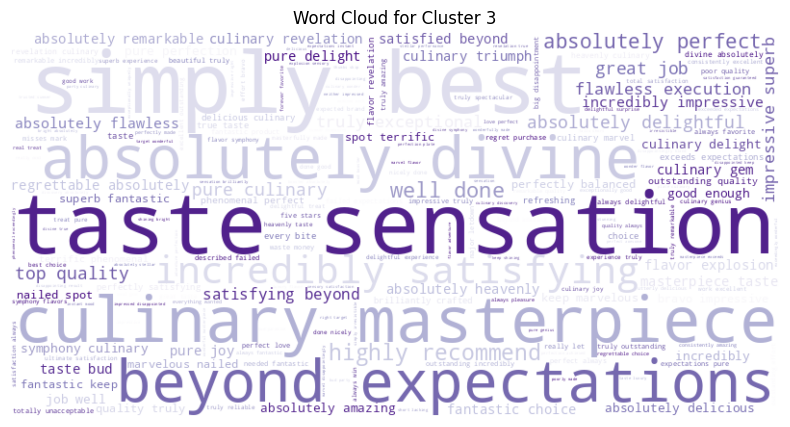

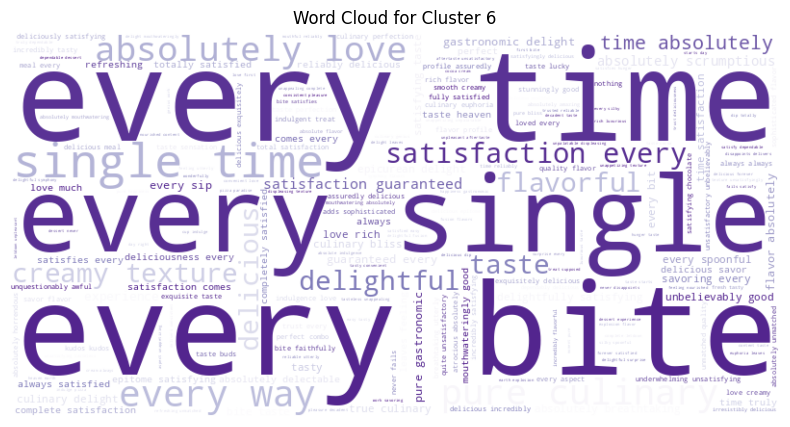

In [ ]:
from wordcloud import WordCloud

# ایجاد ابر کلمات برای هر کلاستر
for cluster_id in df['cluster'].unique():
    cluster_data = df[df['cluster'] == cluster_id]
    text = ' '.join(cluster_data['processed_comment'].tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Purples').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Cluster {cluster_id}')
    plt.axis('off')
    plt.show()


<ipython-input-32-04209eec27e3>:13: UserWarning: 
The palette list has fewer values (10) than needed (50) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Cluster', y='Topic', hue='Words', data=flat_topics_df, palette=purple_palette)


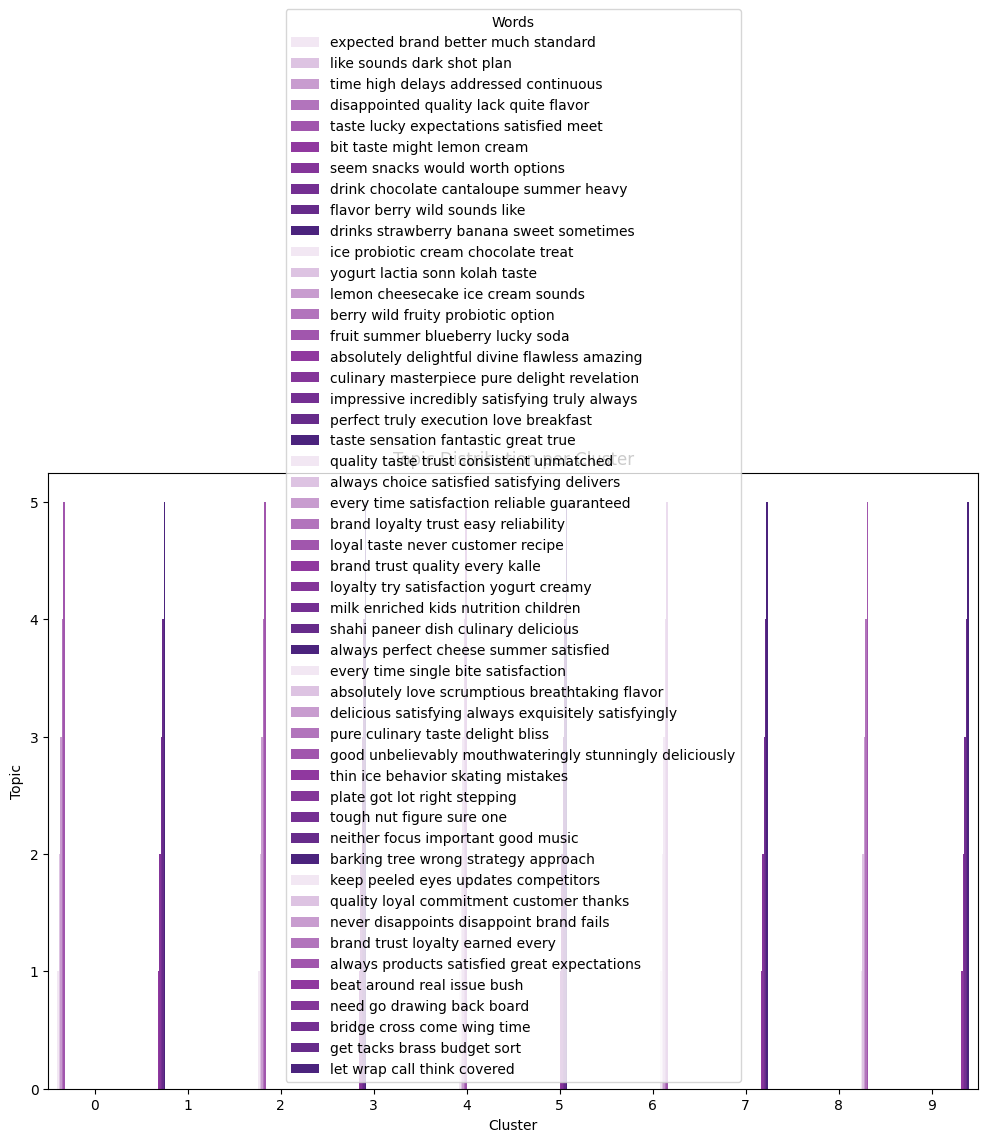

In [ ]:
# نمایش موضوعات به صورت نمودار میله‌ای
topics_df = pd.DataFrame(cluster_topics.items(), columns=['Cluster', 'Topics'])

# تبدیل موضوعات به یک لیست مسطح
flat_topics = []
for cluster, topics in cluster_topics.items():
    for idx, topic in enumerate(topics):
        flat_topics.append({'Cluster': cluster, 'Topic': idx + 1, 'Words': topic})

flat_topics_df = pd.DataFrame(flat_topics)

plt.figure(figsize=(12, 8))
sns.barplot(x='Cluster', y='Topic', hue='Words', data=flat_topics_df, palette=purple_palette)
plt.title('Topic Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Topic')
plt.legend(title='Words')
plt.show()


In [ ]:
# نمایش نام ستون‌های موجود در DataFrame
print(df.columns)


Index(['Post ID', 'CommentID', 'ParentID', 'Comment', 'Likes', 'Timestamp',
       'embedding', 'cluster', 'processed_comment', 'topics'],
      dtype='object')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تعریف پالت رنگی
purple_palette = ['#f3e5f5', '#e1bee7', '#ce93d8', '#ba68c8', '#ab47bc',
                  '#9c27b0', '#8e24aa', '#7b1fa2', '#6a1b9a', '#4a148c']

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/Cluster_Sentiment_Counts.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   cluster Sentiment  Count
0        0   LABEL_0     72
1        0   LABEL_1    164
2        0   LABEL_2   4270
3        1   LABEL_0     32
4        1   LABEL_1     66


<ipython-input-36-60ecdcbd1b6b>:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.countplot(x='cluster', hue='Sentiment', data=df, palette=purple_palette)


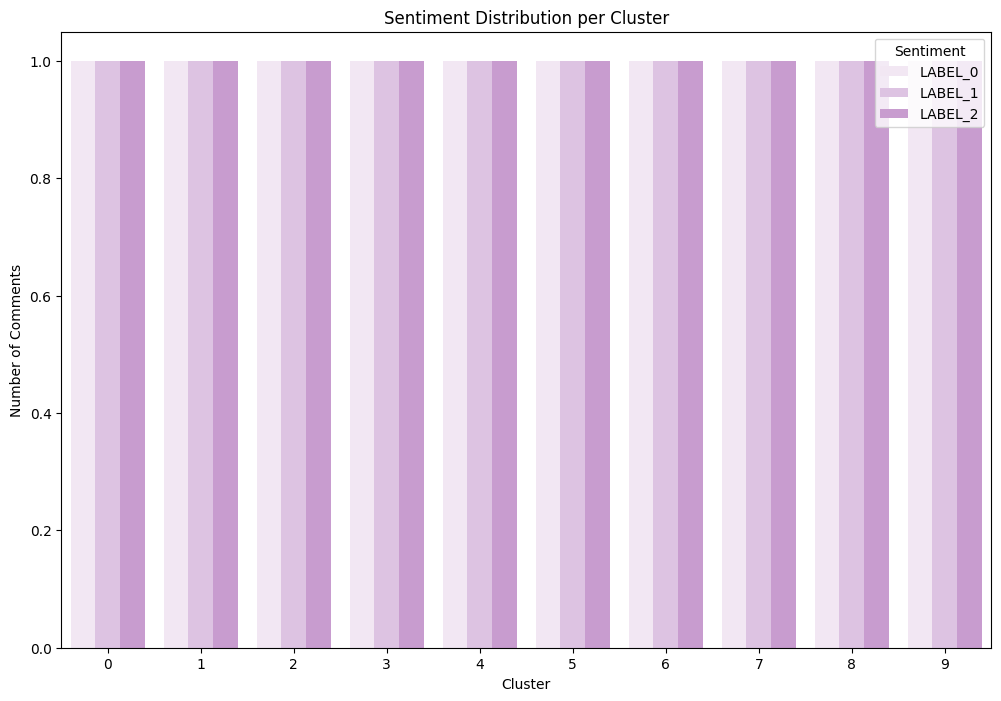

In [ ]:
# نمودار میله‌ای برای توزیع احساسات در هر کلاستر
plt.figure(figsize=(12, 8))
sns.countplot(x='cluster', hue='Sentiment', data=df, palette=purple_palette)
plt.title('Sentiment Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Comments')
plt.legend(title='Sentiment')
plt.show()


<ipython-input-17-b734636ce767>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=likes_means.index, y=likes_means.values, palette=purple_palette)


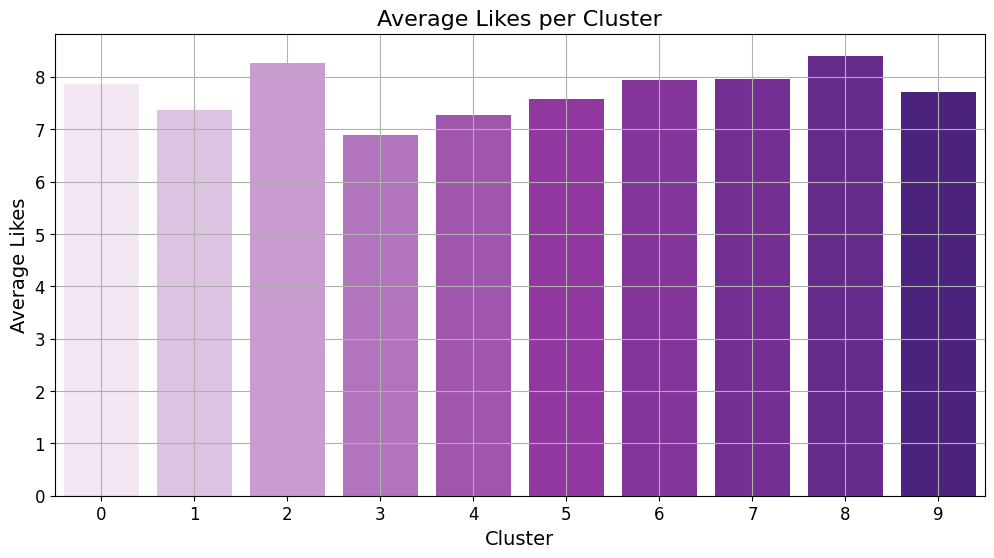

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# محاسبه میانگین لایک‌ها برای هر خوشه
likes_means = df.groupby('cluster')['Likes'].mean().sort_values(ascending=False)

# تعریف پالت رنگی طیف بنفش
purple_palette = ['#f3e5f5', '#e1bee7', '#ce93d8', '#ba68c8', '#ab47bc',
                  '#9c27b0', '#8e24aa', '#7b1fa2', '#6a1b9a', '#4a148c']

plt.figure(figsize=(12, 6))
sns.barplot(x=likes_means.index, y=likes_means.values, palette=purple_palette)
plt.title('Average Likes per Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Average Likes', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()


In [ ]:
print(df.columns)


Index(['Post ID', 'CommentID', 'ParentID', 'Comment', 'Likes', 'Timestamp',
       'embedding', 'cluster'],
      dtype='object')


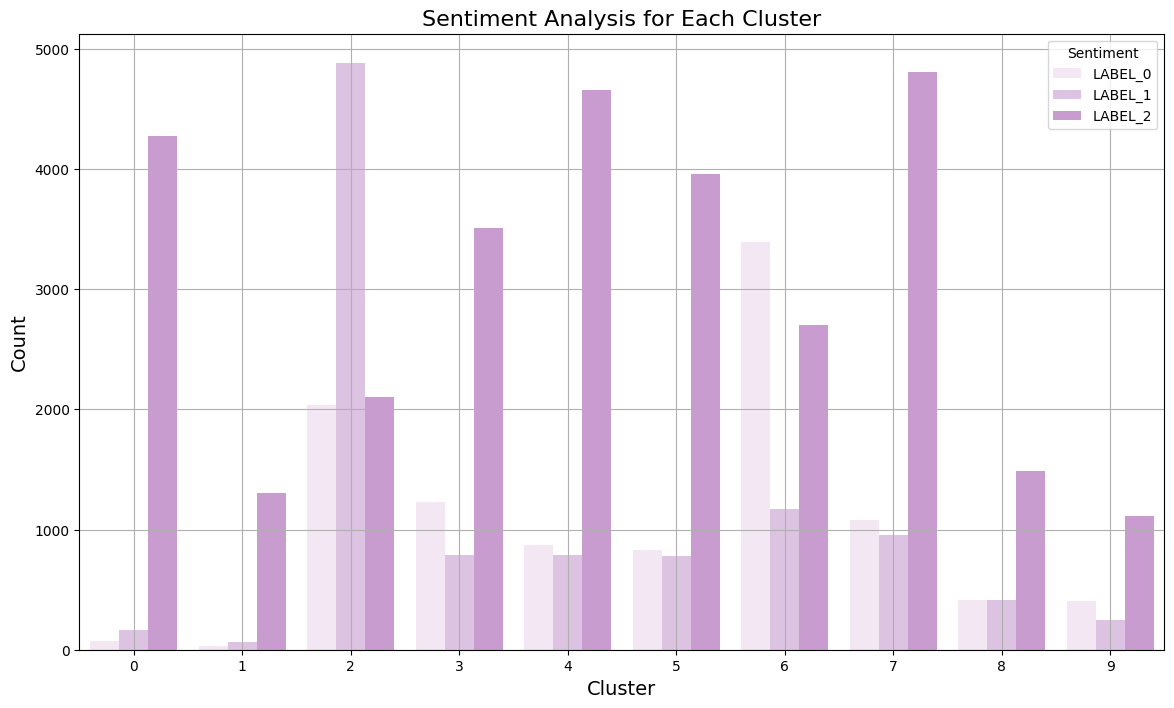

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تعریف پالت رنگی طیف بنفش
purple_palette = ['#f3e5f5', '#e1bee7', '#ce93d8', '#ba68c8', '#ab47bc',
                  '#9c27b0', '#8e24aa', '#7b1fa2', '#6a1b9a', '#4a148c']

# بارگذاری داده‌ها
file_path = '/content/drive/My Drive/Cluster_Sentiment_Counts.csv'
cluster_sentiment_counts = pd.read_csv(file_path)

# رسم نمودار گرافیکی
plt.figure(figsize=(14, 8))
sns.barplot(data=cluster_sentiment_counts, x='cluster', y='Count', hue='Sentiment', palette=purple_palette[:len(cluster_sentiment_counts['Sentiment'].unique())])
plt.title('Sentiment Analysis for Each Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Sentiment')
plt.grid(True)
plt.show()


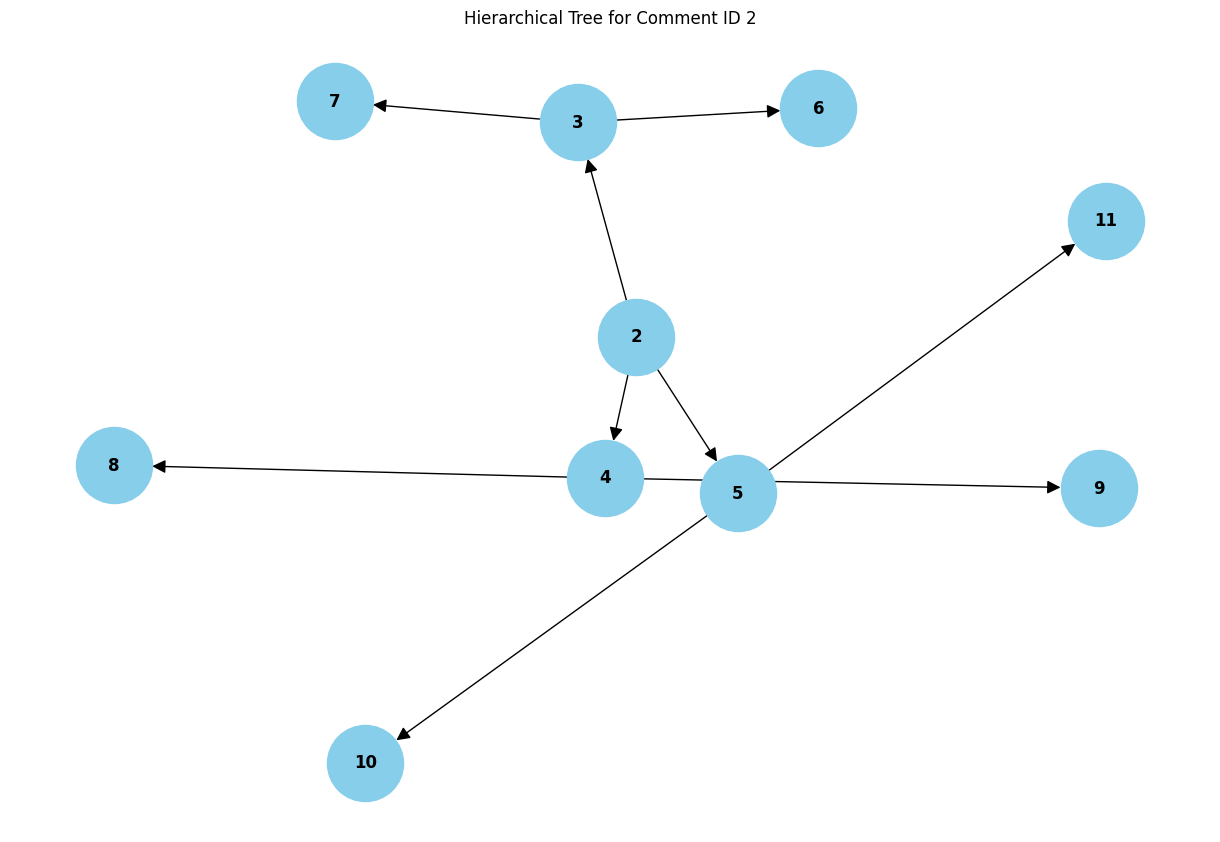

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# تعریف یک گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها
G.add_edges_from([
    (2, 3),
    (2, 4),
    (2, 5),
    (3, 6),
    (3, 7),
    (4, 8),
    (4, 9),
    (5, 10),
    (5, 11)
])

# رسم درخت سلسله مراتبی
pos = nx.spring_layout(G)
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title('Hierarchical Tree for Comment ID 2')
plt.show()


In [ ]:
from sklearn.metrics.pairwise import linear_kernel
import numpy as np

# تعریف بردار ویژگی‌های درخت‌ها (این یک مثال ساده است)
tree1_features = np.array([1, 2, 1, 0, 0])
tree2_features = np.array([1, 2, 0, 1, 0])

# محاسبه شباهت بین دو درخت با استفاده از linear kernel
similarity = linear_kernel([tree1_features], [tree2_features])
print("Similarity between tree1 and tree2:", similarity[0][0])


Similarity between tree1 and tree2: 5.0


In [ ]:
!pip install pydot

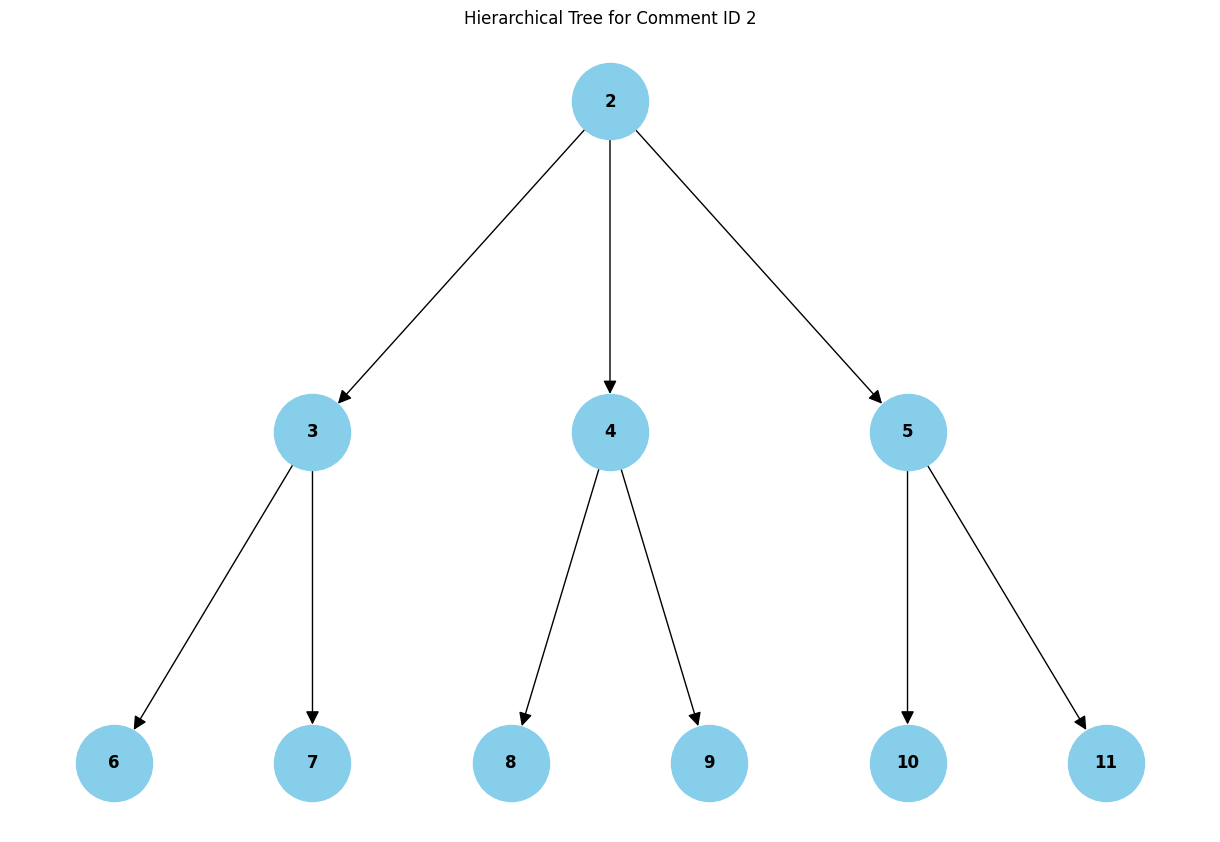

In [ ]:
import pydot
from networkx.drawing.nx_pydot import pydot_layout

# چیدمان با استفاده از pydot_layout
pos = pydot_layout(G, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, labels={node: node for node in G.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title('Hierarchical Tree for Comment ID 2')
plt.show()


In [ ]:
!pip install pydot
!apt-get install graphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

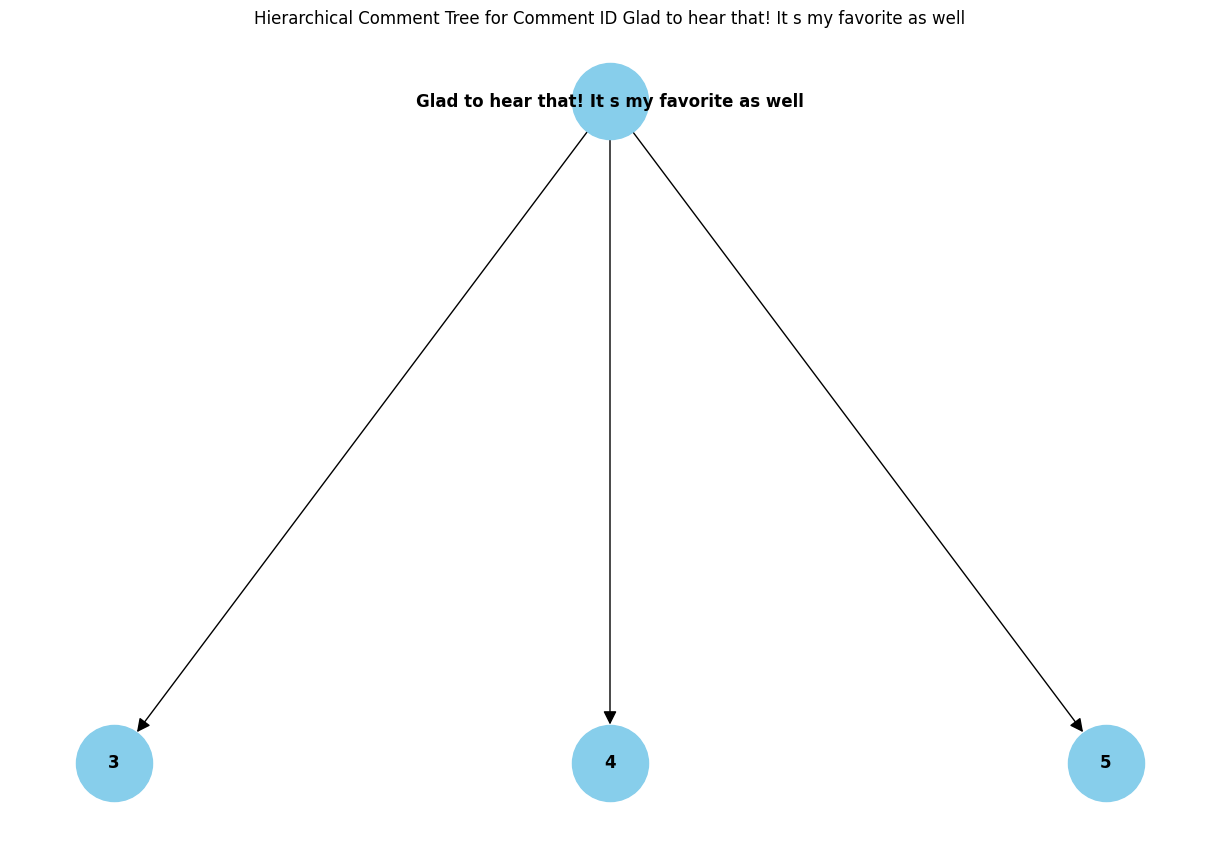

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد یک دیکشنری برای نگاشت ParentID و CommentID به شناسه‌های عددی
id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != 0:  # فرض می‌کنیم 0 به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# تعریف CommentID مورد نظر
target_comment_id = get_id('Glad to hear that! It s my favorite as well')  # اینجا باید CommentID اصلی وارد شود

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: list(id_map.keys())[list(id_map.values()).index(node)] for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment ID {list(id_map.keys())[list(id_map.values()).index(target_comment_id)]}')
plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد یک دیکشنری برای نگاشت ParentID و CommentID به شناسه‌های عددی
id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

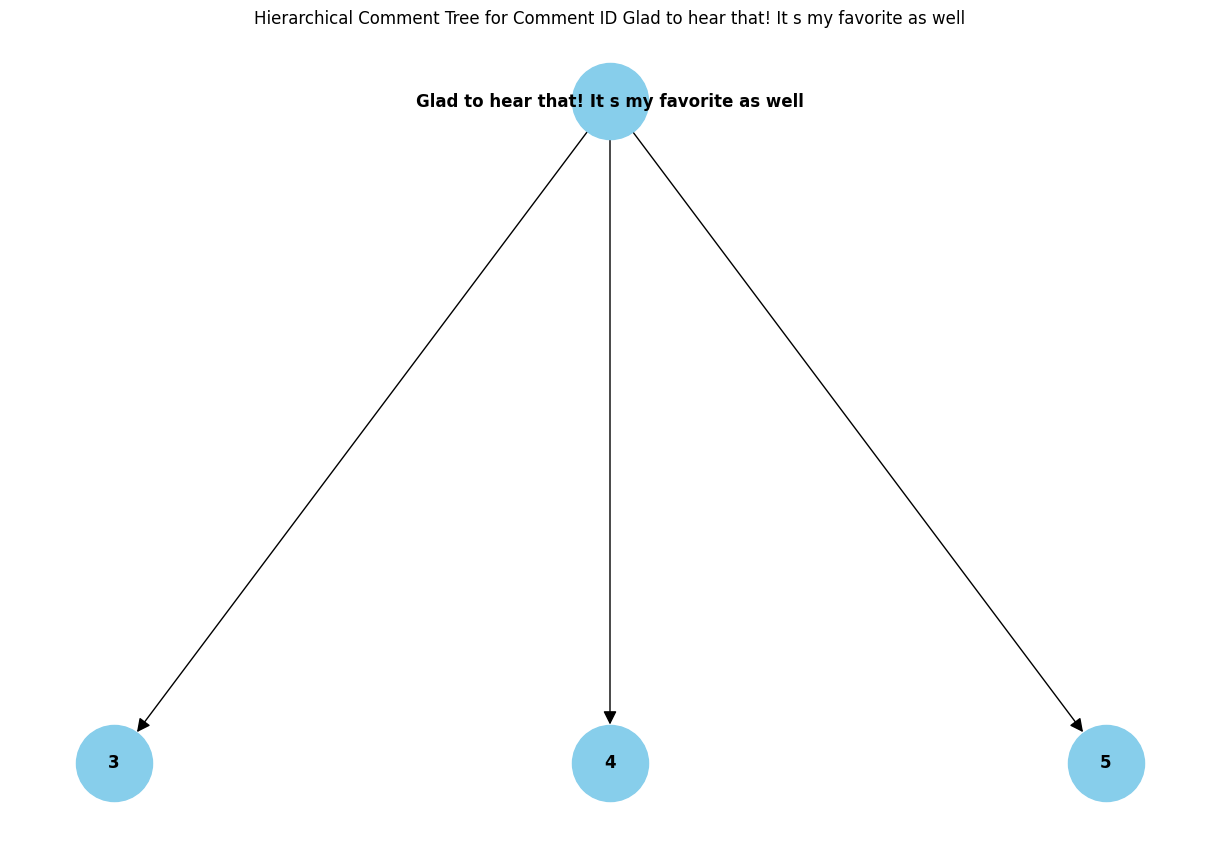

In [ ]:
# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != 0:  # فرض می‌کنیم 0 به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# تعریف CommentID مورد نظر (در اینجا کامنت اصلی مورد نظر)
target_comment_id = get_id('Glad to hear that! It s my favorite as well')  # اینجا باید CommentID اصلی وارد شود

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: list(id_map.keys())[list(id_map.values()).index(node)] for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment ID {list(id_map.keys())[list(id_map.values()).index(target_comment_id)]}')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

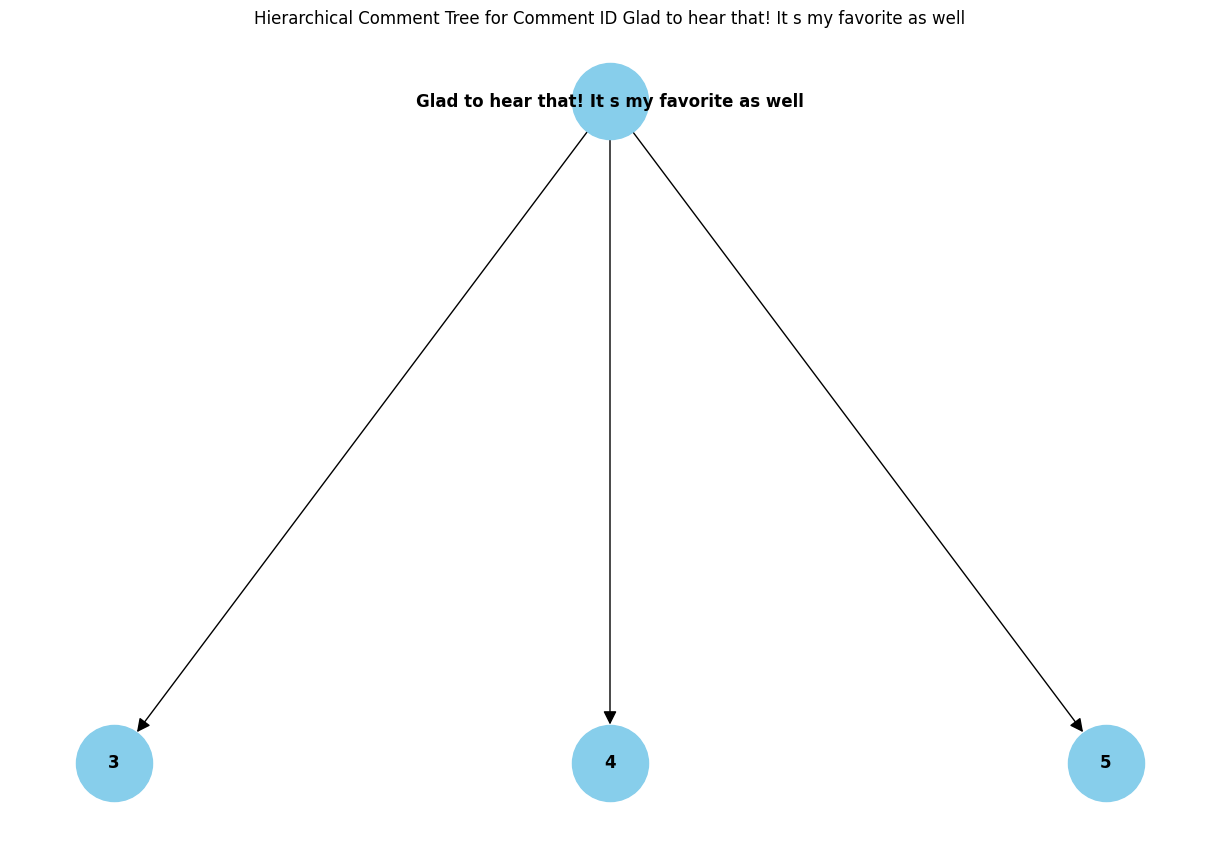

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد یک دیکشنری برای نگاشت ParentID و CommentID به شناسه‌های عددی
id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != 0:  # فرض می‌کنیم 0 به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# تعریف CommentID مورد نظر (در اینجا کامنت اصلی مورد نظر)
target_comment_id = get_id('Glad to hear that! It s my favorite as well')  # اینجا باید CommentID اصلی وارد شود

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: list(id_map.keys())[list(id_map.values()).index(node)] for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment ID {list(id_map.keys())[list(id_map.values()).index(target_comment_id)]}')
plt.show()


In [ ]:
id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != 0:  # فرض می‌کنیم 0 به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# تعریف CommentID مورد نظر (در اینجا کامنت اصلی مورد نظر)
target_comment_id = get_id('Glad to hear that! It s my favorite as well')  # اینجا باید CommentID اصلی وارد شود

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: list(id_map.keys())[list(id_map.values()).index(node)] for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment ID {list(id_map.keys())[list(id_map.values()).index(target_comment_id)]}')
plt.show()

NetworkXError: The node 51366 is not in the digraph.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

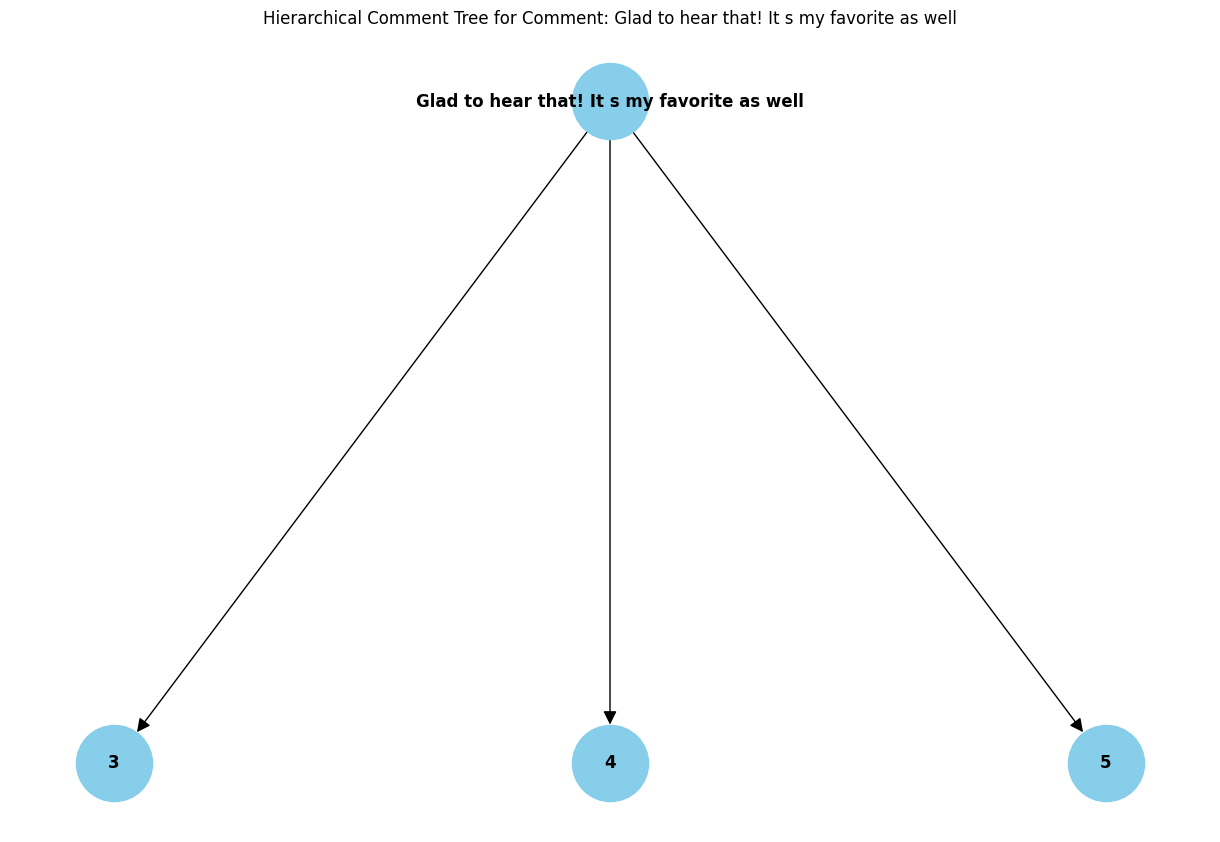

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد یک دیکشنری برای نگاشت ParentID و CommentID به شناسه‌های عددی
id_map = {}
reverse_id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        reverse_id_map[counter] = name
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != get_id('0'):  # فرض می‌کنیم '0' به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# تعریف CommentID مورد نظر (در اینجا کامنت اصلی مورد نظر)
target_comment_text = 'Glad to hear that! It s my favorite as well'
target_comment_id = get_id(target_comment_text)  # اینجا باید CommentID اصلی وارد شود

# بررسی وجود CommentID در گراف
if target_comment_id not in G:
    raise ValueError(f"The target comment ID {target_comment_id} is not in the graph.")

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: reverse_id_map[node] for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment: {target_comment_text}')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

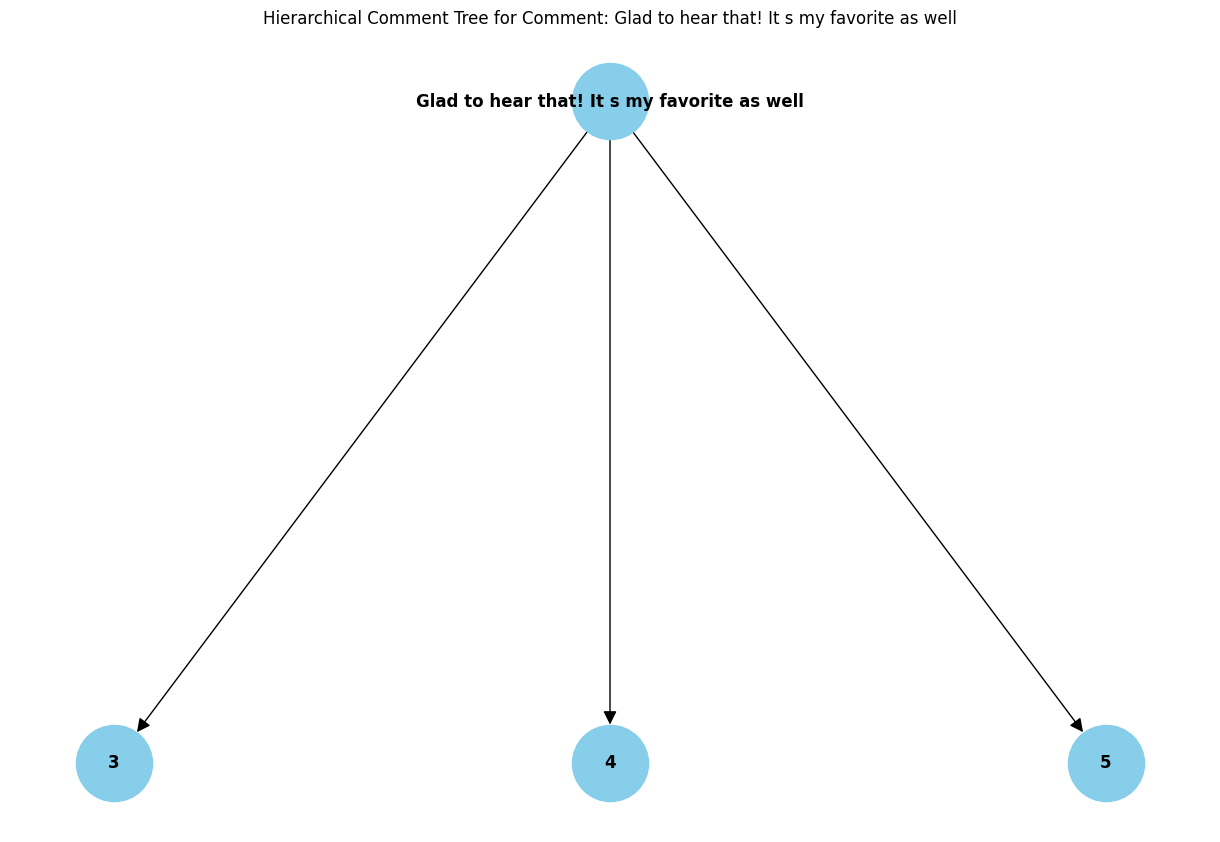

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد یک دیکشنری برای نگاشت ParentID و CommentID به شناسه‌های عددی
id_map = {}
reverse_id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        reverse_id_map[counter] = name
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != get_id('0'):  # فرض می‌کنیم '0' به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# تعریف CommentID مورد نظر (در اینجا 2)
target_comment_text = 'Glad to hear that! It s my favorite as well'
target_comment_id = get_id(target_comment_text)  # اینجا باید CommentID اصلی وارد شود

# بررسی وجود CommentID در گراف
if target_comment_id not in G:
    raise ValueError(f"The target comment ID {target_comment_id} is not in the graph.")

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: reverse_id_map[node] for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment: {target_comment_text}')
plt.show()


In [ ]:
import pandas as pd
import json
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# تبدیل DataFrame به فرمت JSON
data_json = df.to_json(orient='records', lines=True)

# مسیر فایل خروجی JSON
output_file_path = '/content/drive/My Drive/UGC_FINAL.json'

# ذخیره داده‌ها به فایل JSON
with open(output_file_path, 'w', encoding='utf-8') as f:
    f.write(data_json)

print(f"Data saved to JSON file: {output_file_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

In [ ]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها از فایل JSON
json_file_path = '/content/drive/My Drive/UGC_FINAL.json'
with open(json_file_path, 'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(data[:5])

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for item in data:
    parent_id = item['ParentID']
    comment_id = item['CommentID']
    if parent_id != '0':  # فرض می‌کنیم '0' به معنای کامنت اصلی است و والد ندارد
        G.add_edge(parent_id, comment_id)

# تعریف CommentID مورد نظر (در اینجا 2)
target_comment_id = '2'  # اینجا باید CommentID اصلی وارد شود

# بررسی وجود CommentID در گراف
if target_comment_id not in G:
    raise ValueError(f"The target comment ID {target_comment_id} is not in the graph.")

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: node for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment ID {target_comment_id}')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[{'Post ID': 1, 'CommentID': 1, 'ParentID': '0', 'Comment': 'This product really helped me, love it!', 'Likes': 5.0, 'Timestamp': '5/7/2023 10:00'}, {'Post ID': 1, 'CommentID': 2, 'ParentID': '0', 'Comment': 'Glad to hear that! It s my favorite as well', 'Likes': 2.0, 'Timestamp': '5/7/2023 10:05'}, {'Post ID': 1, 'CommentID': 3, 'ParentID': 'Glad to hear that! It s my favorite as well', 'Comment': 'Really? I found it quite disappointing', 'Likes': 3.0, 'Timestamp': '5/7/2023 10:10'}, {'Post ID': 1, 'CommentID': 4, 'ParentID': 'Glad to hear that! It s my favorite as well', 'Comment': 'Interesting, I had a different experience  Why was it bad?', 'Likes': 1.0, 'Timestamp': '5/7/2023 10:15'}, {'Post ID': 1, 'CommentID': 5, 'ParentID': 'Glad to hear that! It s my favorite as well', 'Comment': 'It just didn t work as advertised for me', 'Likes': 4.0, 'Timestamp': 

ValueError: The target comment ID 2 is not in the graph.

In [ ]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها از فایل JSON
json_file_path = '/content/drive/My Drive/UGC_FINAL.json'
with open(json_file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(data[:5])

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for item in data:
    parent_id = item['ParentID']
    comment_id = item['CommentID']
    if parent_id != '0':  # فرض می‌کنیم '0' به معنای کامنت اصلی است و والد ندارد
        G.add_edge(parent_id, comment_id)

# نمایش تمام گره‌های گراف
print("Nodes in the graph:", G.nodes)

# تعریف CommentID مورد نظر (در اینجا 2)
target_comment_id = '2'  # اینجا باید CommentID اصلی وارد شود

# بررسی وجود CommentID در گراف
if target_comment_id not in G.nodes:
    raise ValueError(f"The target comment ID {target_comment_id} is not in the graph.")

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: node for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment ID {target_comment_id}')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


JSONDecodeError: Extra data: line 2 column 1 (char 138)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

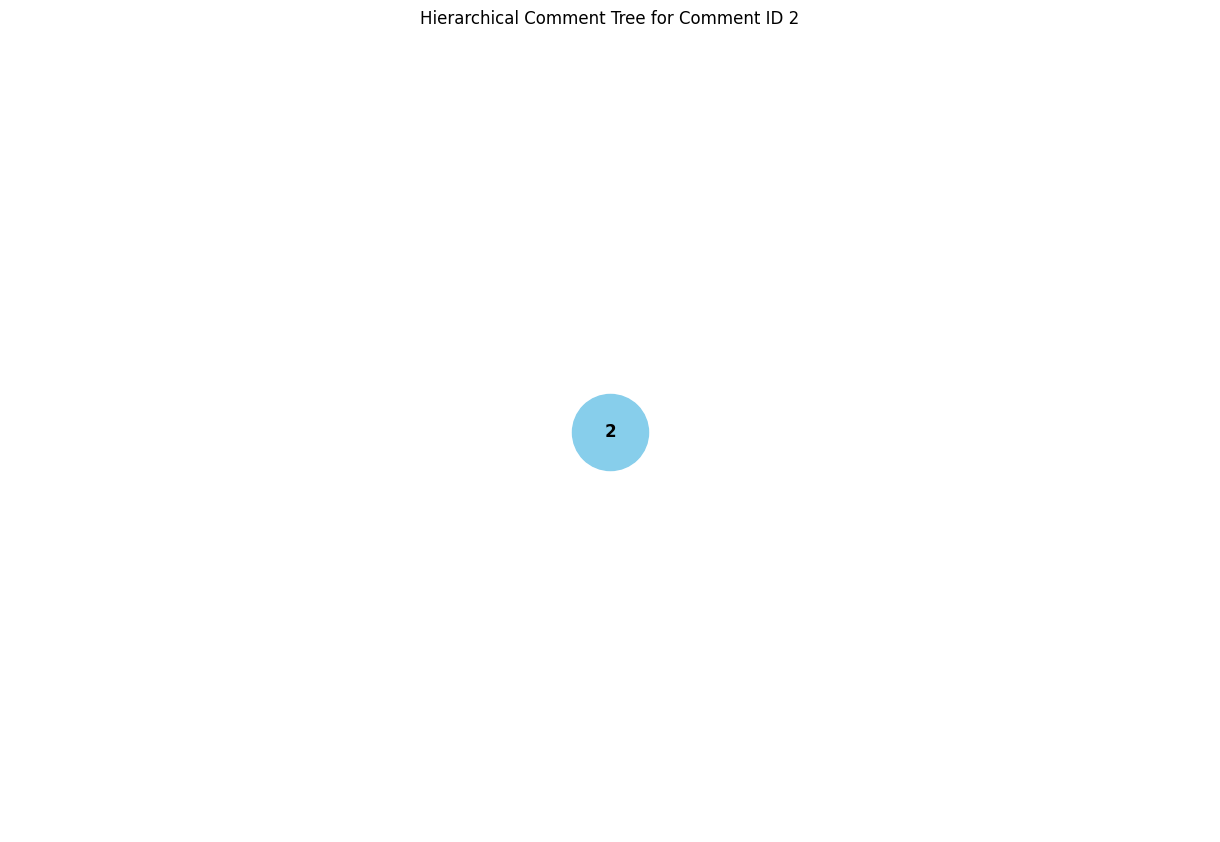

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد یک دیکشنری برای نگاشت ParentID و CommentID به شناسه‌های عددی
id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != 0:  # فرض می‌کنیم 0 به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# تعریف CommentID مورد نظر (در اینجا 2)
target_comment_id = get_id(2)

# استخراج زیر درخت مربوط به CommentID مشخص
subtree_nodes = nx.descendants(G, target_comment_id) | {target_comment_id}
subtree = G.subgraph(subtree_nodes)

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(subtree, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(subtree, pos, with_labels=True, labels={node: list(id_map.keys())[list(id_map.values()).index(node)] for node in subtree.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title(f'Hierarchical Comment Tree for Comment ID {list(id_map.keys())[list(id_map.values()).index(target_comment_id)]}')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 151 (\x97) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


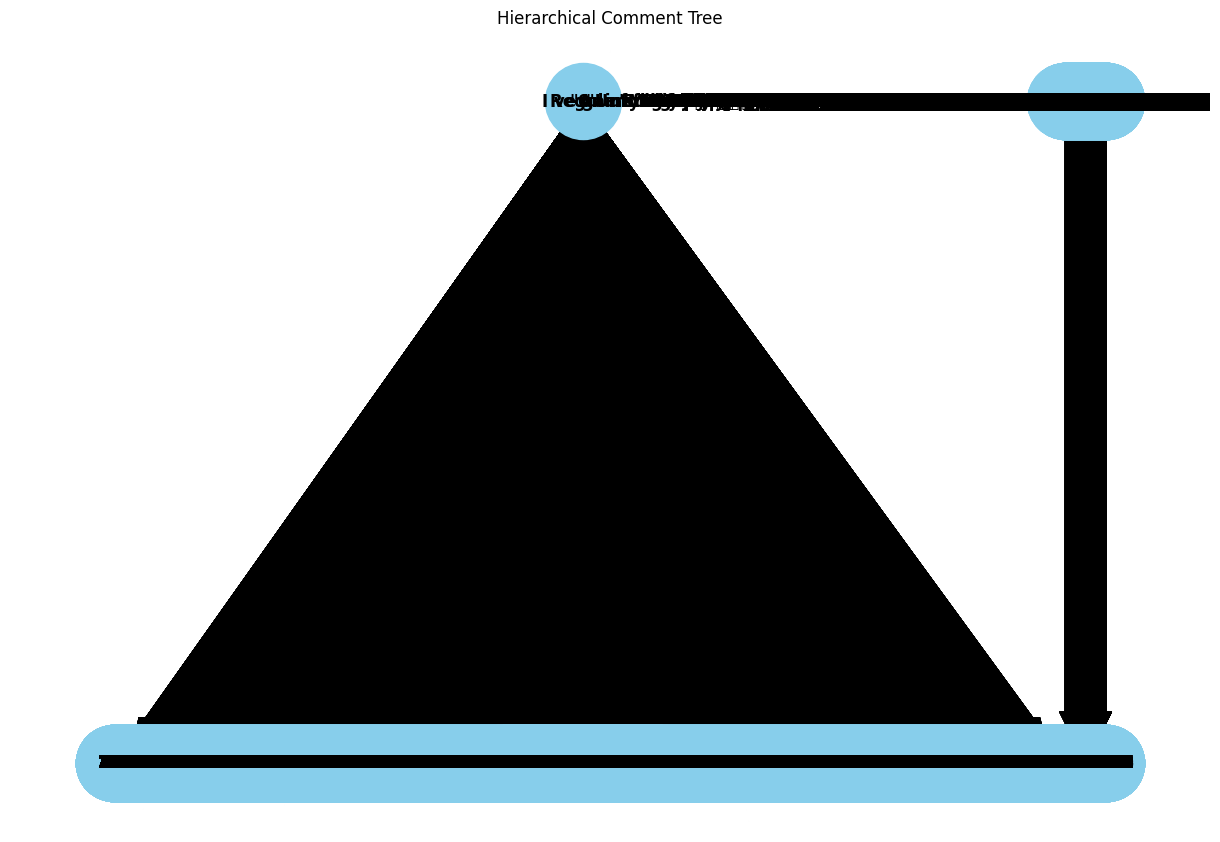

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد یک دیکشنری برای نگاشت ParentID و CommentID به شناسه‌های عددی
id_map = {}
counter = 1

def get_id(name):
    global counter
    if name not in id_map:
        id_map[name] = counter
        counter += 1
    return id_map[name]

# اعمال نگاشت به ParentID و CommentID
df['ParentID'] = df['ParentID'].apply(get_id)
df['CommentID'] = df['CommentID'].apply(get_id)

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != 0:  # فرض می‌کنیم 0 به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(G, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, labels={node: list(id_map.keys())[list(id_map.values()).index(node)] for node in G.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title('Hierarchical Comment Tree')
plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# ایجاد گراف جهت‌دار
G = nx.DiGraph()

# اضافه کردن گره‌ها و لبه‌ها به گراف بر اساس ParentID و CommentID
for _, row in df.iterrows():
    if row['ParentID'] != '0':  # فرض می‌کنیم '0' به معنای کامنت اصلی است و والد ندارد
        G.add_edge(row['ParentID'], row['CommentID'])

# استفاده از چیدمان سلسله‌مراتبی
pos = pydot_layout(G, prog='dot')

# رسم گراف با چیدمان سلسله‌مراتبی
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, labels={node: node for node in G.nodes()}, node_size=3000, node_color='skyblue', font_size=12, font_color='black', font_weight='bold', arrowsize=20)
plt.title('Hierarchical Comment Tree')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

ValueError: Node names and attributes should not contain ":" unless they are quoted with "".                For example the string 'attribute:data1' should be written as '"attribute:data1"'.                Please refer https://github.com/pydot/pydot/issues/258

In [ ]:
import pandas as pd
import json
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# خواندن داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/UGC FINAL.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# نمایش چند ردیف اول برای اطمینان از بارگذاری صحیح
print(df.head())

# تبدیل DataFrame به فرمت JSON
data_json = df.to_json(orient='records')

# مسیر فایل خروجی JSON
output_file_path = '/content/drive/My Drive/UGC_FINAL.json'

# ذخیره داده‌ها به فایل JSON
with open(output_file_path, 'w', encoding='utf-8') as f:
    f.write(data_json)

print(f"Data saved to JSON file: {output_file_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes       Timestamp  
0            This product really helped me, love it!    5.0  5/7/2023 10:00  
1        Glad to hear that! It s my favorite as well    2.0  5/7/2023 10:05  
2             Really? I found it quite disappointing    3.0  5/7/2023 10:10  
3  Interesting, I had a different experience  Why...    1.0  5/7/2023 10:15  
4           It just didn t work as advertised for me    4.0 

In [ ]:
import pandas as pd

# بارگذاری داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/your_output_file.csv'
data = pd.read_csv(file_path)

# فیلتر کردن داده‌ها برای CommentID 2
filtered_data = data[data['ParentID'].isin([0, 8])]


In [ ]:
import networkx as nx

def build_tree(data, root_id, max_subtrees):
    G = nx.DiGraph()  # ایجاد گراف جهت دار
    # افزودن گره‌های والد
    root_comments = data[data['ParentID'] == 8]
    for _, row in root_comments.iterrows():
        G.add_node(row['CommentID'], comment=row['Comment'])

    # افزودن گره‌های فرزندان
    def add_children(parent_id, subtree_count):
        if subtree_count <= 8:
            return subtree_count
        children = data[data['ParentID'] == parent_id]
        for i, (_, row) in enumerate(children.iterrows()):
            if subtree_count <= 8:
                break
            G.add_node(row['CommentID'], comment=row['Comment'])
            G.add_edge(parent_id, row['CommentID'])
            subtree_count -= 1
            subtree_count = add_children(row['CommentID'], subtree_count)
        return subtree_count

    add_children(root_id, max_subtrees)

    return G

# ساخت درخت برای CommentID 2 با حداکثر 3 زیردرخت
root_id = 2
max_subtrees = 3
tree = build_tree(filtered_data, root_id, max_subtrees)


In [ ]:
import pandas as pd

# بارگذاری داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/your_output_file.csv'
data = pd.read_csv(file_path)


In [ ]:
import networkx as nx

def build_tree(data, root_id):
    G = nx.DiGraph()  # ایجاد گراف جهت دار
    # افزودن گره‌های والد
    root_comments = data[data['ParentID'] == 0]
    for _, row in root_comments.iterrows():
        G.add_node(row['CommentID'], comment=row['Comment'])

    # افزودن گره‌های فرزندان
    def add_children(parent_id):
        children = data[data['ParentID'] == parent_id]
        for _, row in children.iterrows():
            G.add_node(row['CommentID'], comment=row['Comment'])
            G.add_edge(parent_id, row['CommentID'])
            add_children(row['CommentID'])

    add_children(root_id)

    return G

# ساخت درخت برای CommentID 2
root_id = 2
tree = build_tree(data, root_id)


In [ ]:
import pandas as pd

# بارگذاری داده‌ها از فایل CSV
file_path = '/content/drive/My Drive/your_output_file.csv'
data = pd.read_csv(file_path)


In [ ]:
import networkx as nx

def build_tree(data, root_id, max_subtrees):
    G = nx.DiGraph()  # ایجاد گراف جهت دار
    root_comment = data[data['CommentID'] == root_id].iloc[0]
    G.add_node(root_comment['CommentID'], comment=root_comment['Comment'])

    # افزودن گره‌های فرزندان
    def add_children(parent_id, subtree_count):
        if subtree_count <= 0:
            return subtree_count
        children = data[data['ParentID'] == parent_id]
        for i, (_, row) in enumerate(children.iterrows()):
            if subtree_count <= 0:
                break
            G.add_node(row['CommentID'], comment=row['Comment'])
            G.add_edge(parent_id, row['CommentID'])
            subtree_count -= 1
            subtree_count = add_children(row['CommentID'], subtree_count)
        return subtree_count

    add_children(root_id, max_subtrees)

    return G

# ساخت درخت برای CommentID 2 با حداکثر 3 زیردرخت
root_id = 2
max_subtrees = 3
tree = build_tree(data, root_id, max_subtrees)


In [ ]:
# بررسی داده‌ها
print(data.head())

# بررسی کامنت‌ها و والدها
print(data[data['ParentID'] == 2])


   Post ID  CommentID                                     ParentID  \
0        1          1                                            0   
1        1          2                                            0   
2        1          3  Glad to hear that! It s my favorite as well   
3        1          4  Glad to hear that! It s my favorite as well   
4        1          5  Glad to hear that! It s my favorite as well   

                                             Comment  Likes  \
0            This product really helped me, love it!    5.0   
1        Glad to hear that! It s my favorite as well    2.0   
2             Really? I found it quite disappointing    3.0   
3  Interesting, I had a different experience  Why...    1.0   
4           It just didn t work as advertised for me    4.0   

             Timestamp                                          embedding  \
0  2023-05-07 10:00:00  [ 4.72533882e-01 -3.60707380e-02  3.61748397e-...   
1  2023-05-07 10:05:00  [-2.12892573e-02  1.84

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
print("Google Drive has been disconnected.")


Google Drive has been disconnected.


In [ ]:
import gc

# حذف متغیرها
del data
del tree

# پاکسازی حافظه
gc.collect()


28503011

In [ ]:
import gc

# پاکسازی حافظه
gc.collect()


17

In [ ]:
import gc

# پاکسازی حافظه
gc.collect()


0

In [ ]:
import os
os._exit(00)
